In [3]:
import numpy as np 
import os 
import matplotlib as mpl 
import matplotlib.pyplot as plt 
from matplotlib.colorbar import ColorbarBase 
from astropy.io import fits 
from astropy.visualization import PercentileInterval 
from copy import copy 
mpl.rc('xtick',direction='in') 
mpl.rc('ytick',direction='in') 
plt.rc('font',family='sans-serif',serif='Helvetica',size=10) 
params = {'text.usetex': False, 'mathtext.fontset': 'cm', 'mathtext.default': 'regular'} 
plt.rcParams.update(params) 

gname = 'SNR10Res10mod' 
outfolder = '/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.05_TP450_VRk0.09_TP300_INC60/second_step_check_sinw/' 
twostage = 1 
xmin, xmax = 238, 562
ymin, ymax = 238, 562

if twostage: rad,inc,pa,xpos,ypos,vsys = np.genfromtxt(outfolder+'rings_final2.txt',usecols=(1,4,5,9,10,11),unpack=True) 
else: rad,inc,pa,xpos,ypos,vsys = np.genfromtxt(outfolder+'rings_final1.txt',usecols=(1,4,5,9,10,11),unpack=True) 
xcen_m,ycen_m,inc_m,pa_m,vsys_m=np.nanmean((xpos,ypos,inc,pa,vsys),axis=1) 
xcen, ycen = xcen_m-xmin, ycen_m-ymin 

# Opening maps and retrieving intensity map units
f0 = fits.open(outfolder+'/maps/'+gname+'_0mom.fits') 
f1 = fits.open(outfolder+'/maps/'+gname+'_1mom.fits') 
f2 = fits.open(outfolder+'/maps/'+gname+'_2mom.fits') 
bunit = f0[0].header['BUNIT'] 
bunit = bunit.replace(' ', '').lower() 
# Now plotting moment maps 
mom0 = f0[0].data[ymin:ymax+1,xmin:xmax+1] 
mom1 = f1[0].data[ymin:ymax+1,xmin:xmax+1] 
mom2 = f2[0].data[ymin:ymax+1,xmin:xmax+1] 
maskmap = np.copy(mom1) 
maskmap[mom1==mom1] = 1 

files_mod0, files_mod1, files_mod2 = [], [], [] 

成功保存图表: SNR10Res10mod_velocity_map_azim.pdf


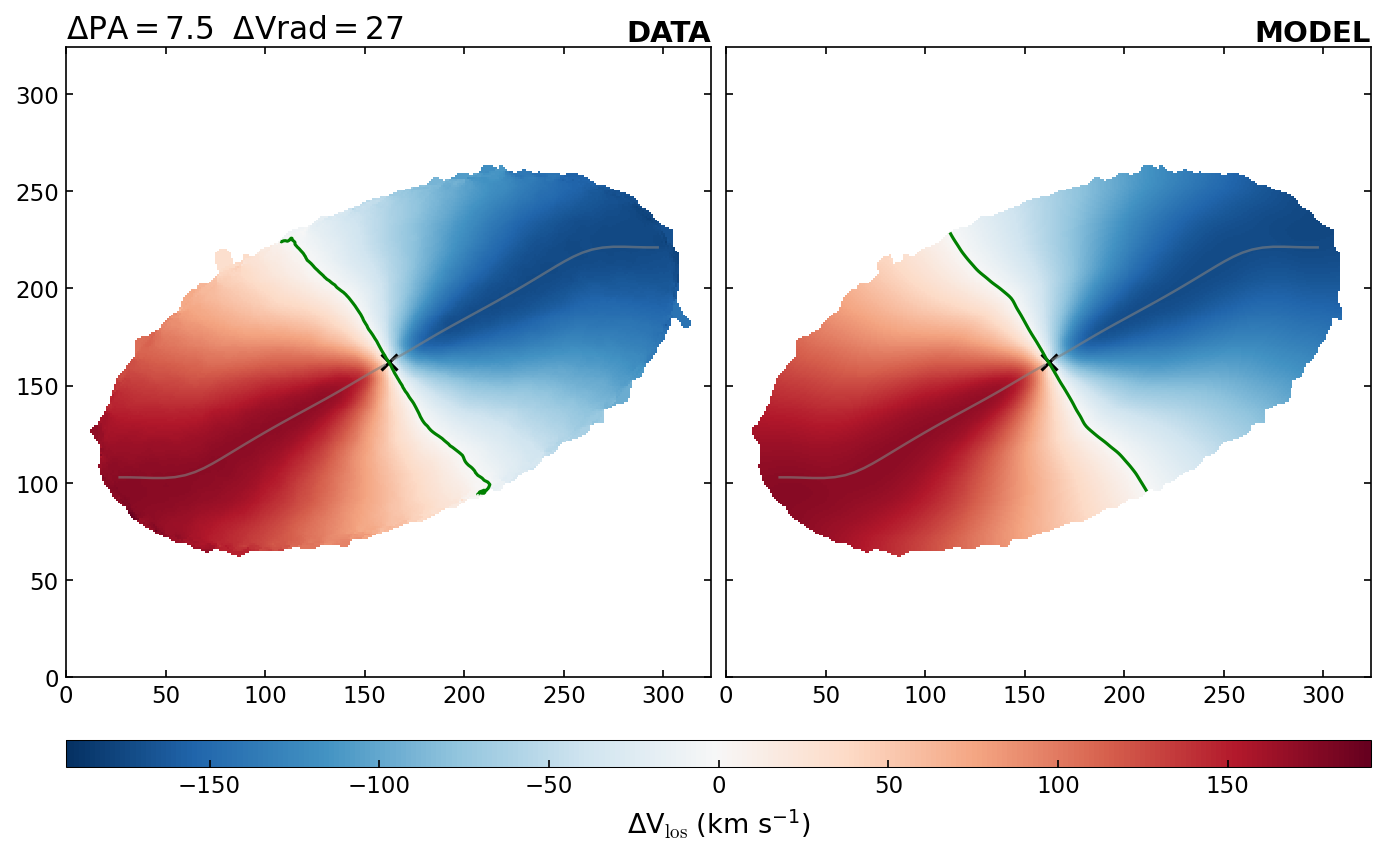

所有处理已完成。


In [9]:
#######################################################################
#### 修正版：动学图对比脚本 (DATA vs MODEL)                        ####
#######################################################################
import numpy as np 
import os 
import matplotlib as mpl 
import matplotlib.pyplot as plt 
from matplotlib.colorbar import ColorbarBase 
from astropy.io import fits 
from astropy.visualization import PercentileInterval 
from copy import copy 

# --- 全局样式设置 (修复了之前的 KeyError) ---
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rc('font', family='sans-serif', size=11) 
params = {'text.usetex': False, 'mathtext.fontset': 'cm', 'mathtext.default': 'regular'} 
plt.rcParams.update(params) 

# --- 路径与参数配置 ---
# 请确保这些路径在你的机器上是正确的
gname = 'SNR10Res10mod' 
outfolder = '/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.05_TP450_VRk0.09_TP300_INC60/second_step_check_sinw/' 
twostage = 1 
xmin, xmax = 238, 562
ymin, ymax = 238, 562

# 读取模型环参数 (用于中心点、倾角和位置角)
rings_file = 'rings_final2.txt' if twostage else 'rings_final1.txt'


try:
    rad, inc, pa, xpos, ypos, vsys = np.genfromtxt(outfolder + rings_file, usecols=(1, 4, 5, 9, 10, 11), unpack=True) 
    xcen_m, ycen_m, inc_m, pa_m, vsys_m = np.nanmean((xpos, ypos, inc, pa, vsys), axis=1) 
except Exception as e:
    print(f"Error loading rings file: {e}")
    # 备用：如果文件读取失败，请检查路径
    raise

xcen, ycen = xcen_m - xmin, ycen_m - ymin 

# --- 读取观测数据 (DATA) ---
f1 = fits.open(outfolder + '/maps/' + gname + '_1mom.fits') 
mom1 = f1[0].data[ymin:ymax+1, xmin:xmax+1] 
# 生成掩模：处理 NaN 值，使绘图背景干净
maskmap = np.where(np.isnan(mom1), np.nan, 1) 

# 寻找模型文件 (MODEL)
files_mod1 = sorted([f for f in os.listdir(outfolder + '/maps/') if ('1mom.fits' in f and ('azim' in f or 'local' in f))])

# 绘图基础参数
ext = [0, xmax - xmin, 0, ymax - ymin] 
rad_pix = rad / 4  # 假设像素比例
interval = PercentileInterval(99.5) 
cmap_vel = plt.get_cmap('RdBu_r') # 经典的红蓝多色标，中心为白色

# --- 循环处理每个模型文件 ---
for k, mod_file in enumerate(files_mod1): 
    # 读取模型 Moment 1
    mom1_mod = fits.open(outfolder + '/maps/' + mod_file)[0].data[ymin:ymax+1, xmin:xmax+1] 
    
    # 计算视线速度偏移 delta_V = V_obs - V_sys
    data_plot = mom1 - vsys_m
    model_plot = mom1_mod - vsys_m
    to_plot = [data_plot, model_plot]
    titles = ['DATA', 'MODEL']

    # 创建画布
    fig = plt.figure(figsize=(10, 6), dpi=150)
    
    # 子图布局控制 [left, bottom, width, height]
    x_len, y_len = 0.43, 0.7
    gap = 0.01  # 两图之间的空隙
    
    # 统一色标量程：确保 0 km/s 在色标中央
    vmax_val = 1.1 * np.nanmax(np.abs(interval.get_limits(model_plot)))
    norm = mpl.colors.Normalize(vmin=-vmax_val, vmax=vmax_val)

    for j in range(2):
        ax = fig.add_axes([0.07 + j*(x_len + gap), 0.22, x_len, y_len])
        
        # 1. 绘制速度场
        im = ax.imshow(to_plot[j] * maskmap, origin='lower', cmap=cmap_vel, norm=norm, 
                       aspect='auto', extent=ext, interpolation='nearest')
        
        # 2. 绘制星系中心 (黑十字)
        ax.plot(xcen, ycen, 'x', color='black', markersize=8, mew=1.5)
        
        # 3. 绘制运动学长轴 (PA 灰线)
        if len(rad_pix) > 5:
            x_p = rad_pix * np.cos(np.radians(pa - 90))
            y_p = rad_pix * np.sin(np.radians(pa - 90))
            ax.plot(xcen - x_p, ycen - y_p, '-', color='grey', lw=1.2, alpha=0.6)
            ax.plot(xcen + x_p, ycen + y_p, '-', color='grey', lw=1.2, alpha=0.6)
        
        # 4. 绘制零速度线 (绿色实线，对应图中的绿色波浪线)
        # 注意：这里会根据速度场自动提取 0 值位置
        ax.contour(to_plot[j] * maskmap, levels=[0], colors='green', 
                   origin='lower', extent=ext, linewidths=1.5)
        
        # 5. 子图标注与坐标
        ax.set_title(titles[j], loc='right', pad=-20, fontsize=14, fontweight='bold')
        ax.set_xlim(ext[0], ext[1])
        ax.set_ylim(ext[2], ext[3])
        if j > 0: 
            ax.set_yticklabels([]) # 右图隐藏 Y 轴刻度标签
        
    # 在画布左上角添加星系名称 (如图片所示)
    fig.text(0.07, 0.93, r'$\Delta PA=7.5\ \ \Delta Vrad=27$', fontsize=15)

    # 绘制底部的统一色标 (Horizontal Colorbar)
    cb_width = 2 * x_len + gap
    cbax = fig.add_axes([0.07, 0.12, cb_width, 0.03])
    cb = ColorbarBase(cbax, orientation='horizontal', cmap=cmap_vel, norm=norm)
    cb.set_label(r'$\Delta V_{\mathrm{los}}$ (km s$^{-1}$)', fontsize=13)
    cb.outline.set_linewidth(0.5)
    cb.solids.set_edgecolor("face")

    # 保存结果
    suffix = '_azim' if 'azim' in mod_file else '_local'
    save_name = f"{gname}_velocity_map{suffix}.pdf"
    #plt.savefig(outfolder + save_name, bbox_inches='tight')
    print(f"成功保存图表: {save_name}")
    plt.show()

print("所有处理已完成。")

Saved: /net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.05_TP450_VRk0.09_TP300_INC60/second_step_check_sinw/SNR10Res10mod_pv_comparison_azim.png


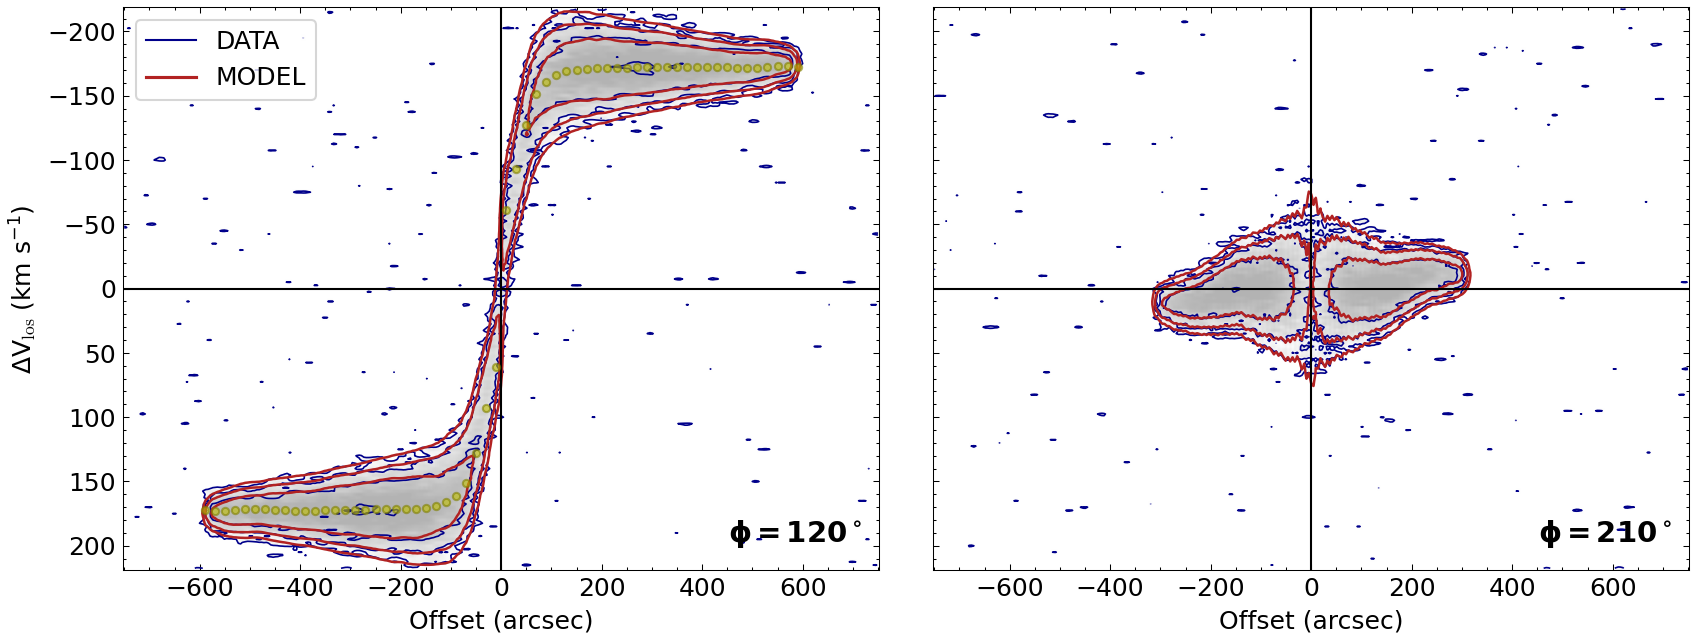

In [5]:
#################################################################################
#### 修正版：并排显示位置-速度图 (Position-Velocity Slices)                  ####
#################################################################################
import numpy as np 
import os 
import matplotlib as mpl 
import matplotlib.pyplot as plt 
from astropy.io import fits 
from astropy.visualization import PowerStretch 
from astropy.visualization.mpl_normalize import ImageNormalize 
from astropy.visualization import PercentileInterval 

# --- 全局样式设置 ---
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
mpl.rcParams['contour.negative_linestyle'] = 'solid' 
plt.rc('font', family='sans-serif', size=10) 
params = {'text.usetex': False, 'mathtext.fontset': 'cm', 'mathtext.default': 'regular'} 
plt.rcParams.update(params) 

# --- 路径与参数配置 ---
gname = 'SNR10Res10mod' 
outfolder = '/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.05_TP450_VRk0.09_TP300_INC60/second_step_check_sinw/' 
twostage = 1 
plotmask = 1 
zmin, zmax = 13, 187

# 加载环参数
rings_file = 'rings_final2.txt' if twostage else 'rings_final1.txt'
rad, vrot, inc, pa, vsys = np.genfromtxt(outfolder + rings_file, usecols=(1,2,4,5,11), unpack=True) 

# 准备文件列表
files_pva_mod = sorted([f for f in os.listdir(outfolder + 'pvs/') if ('pv_a_azim.fits' in f or 'pv_a_local.fits' in f)])
files_pvb_mod = sorted([f for f in os.listdir(outfolder + 'pvs/') if ('pv_b_azim.fits' in f or 'pv_b_local.fits' in f)])

# --- 读取观测数据 PV 图 ---
image_maj = fits.open(outfolder + 'pvs/' + gname + '_pv_a.fits') 
image_min = fits.open(outfolder + 'pvs/' + gname + '_pv_b.fits') 
head = [image_maj[0].header, image_min[0].header] 

# 计算 WCS 坐标
crpixpv = np.array([head[0]['CRPIX1'], head[1]['CRPIX1']]) 
cdeltpv = np.array([head[0]['CDELT1'], head[1]['CDELT1']]) 
crvalpv = np.array([head[0]['CRVAL1'], head[1]['CRVAL1']]) 
xminpv, xmaxpv = np.floor(crpixpv - 1 - 162), np.ceil(crpixpv - 1 + 162) 

data_maj = image_maj[0].data[zmin:zmax+1, int(xminpv[0]):int(xmaxpv[0])+1] 
data_min = image_min[0].data[zmin:zmax+1, int(xminpv[1]):int(xmaxpv[1])+1] 

xmin_wcs = ((xminpv + 1 - 0.5 - crpixpv) * cdeltpv + crvalpv) * 3600
xmax_wcs = ((xmaxpv + 1 + 0.5 - crpixpv) * cdeltpv + crvalpv) * 3600
zmin_wcs, zmax_wcs = 255.25, -182.25
vsys_m = np.nanmean(vsys) 

# 设置等值线和归一化
cont = 0.000675824
v_levels = np.array([1, 2, 4, 8, 16, 32, 64]) * cont 
norm = ImageNormalize(vmin=cont, vmax=data_maj.max()*0.8, stretch=PowerStretch(0.5)) 

# 计算旋转曲线叠加点 (用于主轴图)
radius_pts = np.concatenate((rad, -rad)) 
pamaj_av, pamin_av = 120.265, 210.265
costh = np.cos(np.deg2rad(np.abs(pa - pamaj_av))) 

vlos_pts = np.concatenate((vsys + vrot * np.sin(np.deg2rad(inc)) * costh, 
                           vsys - vrot * np.sin(np.deg2rad(inc)) * costh)) - vsys_m
vlos1 = vsys+vrot*np.sin(np.deg2rad(inc))*costh 
vlos2 = vsys-vrot*np.sin(np.deg2rad(inc))*costh 
reverse = True 
if reverse: vlos1, vlos2 = vlos2, vlos1 
vlos_pts = np.concatenate((vlos1,vlos2)) - vsys_m

# 绘图范围
ext = [[xmin_wcs[0], xmax_wcs[0], zmin_wcs - vsys_m, zmax_wcs - vsys_m],
       [xmin_wcs[1], xmax_wcs[1], zmin_wcs - vsys_m, zmax_wcs - vsys_m]] 
labsize = 12
palab = [r'$\phi = %i^\circ$' % np.round(pamaj_av), r'$\phi = %i^\circ$' % np.round(pamin_av)] 

# --- 循环绘制每个模型的对比图 ---
for k in range(len(files_pva_mod)): 
    im_mod_maj = fits.open(outfolder + 'pvs/' + files_pva_mod[k]) 
    im_mod_min = fits.open(outfolder + 'pvs/' + files_pvb_mod[k]) 
    d_mod_maj = im_mod_maj[0].data[zmin:zmax+1, int(xminpv[0]):int(xmaxpv[0])+1] 
    d_mod_min = im_mod_min[0].data[zmin:zmax+1, int(xminpv[1]):int(xmaxpv[1])+1] 
    
    toplot_data = [data_maj, data_min]
    toplot_mod = [d_mod_maj, d_mod_min]

    # 创建宽画布适应并排布局
    fig = plt.figure(figsize=(12, 5), dpi=150) 
    x_len, y_len = 0.42, 0.75
    gap = 0.03
    
    for i in range(2): 
        ax = fig.add_axes([0.08 + i*(x_len + gap), 0.15, x_len, y_len]) 
        
        # 1. 绘制灰度图 (DATA)
        ax.imshow(toplot_data[i], origin='lower', cmap='Greys', norm=norm, extent=ext[i], aspect='auto', alpha=0.3) 
        
        # 2. 绘制 DATA 等值线 (蓝色)
        c_data = ax.contour(toplot_data[i], v_levels, origin='lower', linewidths=0.8, colors='#00008B', extent=ext[i]) 
        
        # 3. 绘制 MODEL 等值线 (红色)
        c_mod = ax.contour(toplot_mod[i], v_levels, origin='lower', linewidths=1.2, colors='#B22222', extent=ext[i]) 
        
        # 4. 辅助线与标注
        ax.axhline(y=0, color='black', lw=1) 
        ax.axvline(x=0, color='black', lw=1) 
        ax.set_xlabel('Offset (arcsec)', fontsize=labsize) 
        ax.text(0.8, 0.05, palab[i], transform=ax.transAxes, fontsize=labsize+2, fontweight='bold') 

        if i == 0:
            ax.set_ylabel(r'$\Delta V_{\mathrm{los}}$ (km s$^{-1}$)', fontsize=labsize)
            # 叠加旋转曲线点
            ax.plot(radius_pts, vlos_pts, 'y.', markersize=7, markeredgecolor='olive', alpha=0.6)
            # 添加图例
            from matplotlib.lines import Line2D
            legend_elements = [Line2D([0], [0], color='#00008B', lw=1, label='DATA'),
                               Line2D([0], [0], color='#B22222', lw=1.5, label='MODEL')]
            ax.legend(handles=legend_elements, loc='upper left', frameon=True, fontsize=12)
        else:
            ax.set_yticklabels([]) # 隐藏右图 Y 轴标签

    # 保存文件
    suffix = '_azim' if 'azim' in files_pva_mod[k] else '_local'
    save_path = outfolder + gname + '_pv_comparison' + suffix + '.png'
    #fig.savefig(save_path, bbox_inches='tight')
    #plt.close(fig)
    print(f"Saved: {save_path}")

image_maj.close() 
image_min.close()

In [29]:
model="ring_v200_R50_PAk0.05_TP450_VRk0.09_TP300_INC60/second_step_check_sinw/rings_final2.txt"
True_value=INITIAL_1123   = "/net/dataserver3/data/users/linn/para_initial/test_more_model/model1123/"

In [30]:
RING_BASE      = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/"
RING_MODEL1123 = RING_BASE + "model1123/"

INITIAL_1123   = "/net/dataserver3/data/users/linn/para_initial/test_more_model/model1123/"
galaxy="ring_v200_R50_PAk0.05_TP450_VRk0.09_TP300_INC60"


In [31]:
RING_BASE      = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/"
RING_MODEL1123 = RING_BASE + "model1123/"

INITIAL_1123   = "/net/dataserver3/data/users/linn/para_initial/test_more_model/model1123/"
galaxy="ring_v200_R50_PAk0.05_TP450_VRk0.09_TP300_INC60"

recovered_value=RING_MODEL1123+galaxy+"/second_step_check_sinw/rings_final2.txt"
true_value=INITIAL_1123+galaxy+".txt"
error = RING_MODEL1123+galaxy+"/bootstrap_error.txt"
import pandas as pd
recorver=pd.read_csv(recovered_value, delimiter=r"\s+")
true_=pd.read_csv(true_value, delimiter=r"\s+")
error_=pd.read_csv(error, delimiter=r"\s+")

In [34]:
import pandas as pd
recorver=pd.read_csv(recovered_value, delimiter=r"\s+")
true_=pd.read_csv(true_value, delimiter=r"\s+")

In [36]:
true_

,RAD(arcs),VROT(km/s),DISP(km/s),P.A.(deg),VRAD(km/s),INC(deg),DENS
0,10,39.475064,29.405960,120.0,-0.0,60.0,2.196077
1,30,107.409913,28.252936,120.0,-0.0,60.0,2.559850
2,50,152.318831,27.145123,120.0,-0.0,60.0,2.877734
3,70,177.070330,26.080747,120.0,-0.0,60.0,3.143970
4,90,189.361203,25.058106,120.0,-0.0,60.0,3.356348
5,110,195.148626,24.075564,120.0,-0.0,60.0,3.515331
6,130,197.805480,23.131548,120.0,-0.0,60.0,3.623302
7,150,199.010951,22.224547,120.0,-0.0,60.0,3.683959
8,170,199.554986,21.353110,120.0,-0.0,60.0,3.701823
9,190,199.799920,20.515842,120.0,-0.0,60.0,3.681859


In [35]:
recorver

,#RAD(Kpc),RAD(arcs),VROT(km/s),DISP(km/s),INC(deg),P.A.(deg),Z0(pc),Z0(arcs),SIG(E20),XPOS(pix),YPOS(pix),VSYS(km/s),VRAD(km/s)
0,0.025,10.0,71.150,15.880,58.907,123.750,5.055,2.0,1.0,400.0,400.0,36.489,-4.688
1,0.076,30.0,108.661,26.234,58.907,120.711,5.055,2.0,1.0,400.0,400.0,36.489,0.054
2,0.126,50.0,148.980,29.041,58.907,120.504,5.055,2.0,1.0,400.0,400.0,36.489,2.461
3,0.177,70.0,176.677,28.679,58.907,120.687,5.055,2.0,1.0,400.0,400.0,36.489,-0.807
4,0.227,90.0,188.076,27.148,58.907,120.817,5.055,2.0,1.0,400.0,400.0,36.489,3.045
5,0.278,110.0,194.073,26.324,58.907,120.830,5.055,2.0,1.0,400.0,400.0,36.489,0.255
6,0.329,130.0,197.619,24.768,58.907,120.749,5.055,2.0,1.0,400.0,400.0,36.489,1.208
7,0.379,150.0,198.872,23.794,58.907,120.616,5.055,2.0,1.0,400.0,400.0,36.489,0.077
8,0.430,170.0,199.726,22.392,58.907,120.471,5.055,2.0,1.0,400.0,400.0,36.489,0.849
9,0.480,190.0,199.923,21.545,58.907,120.336,5.055,2.0,1.0,400.0,400.0,36.489,0.204


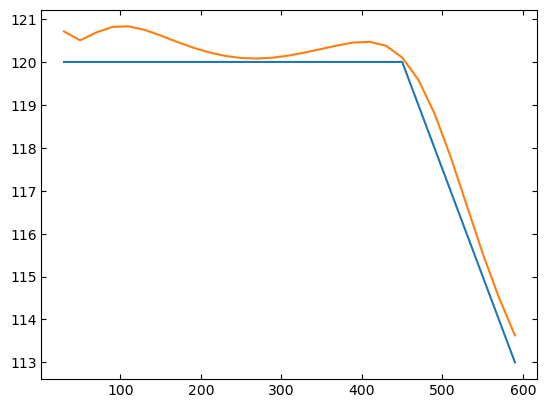

In [40]:
plt.plot(true_["RAD(arcs)"][1:],true_["P.A.(deg)"][1:])
plt.plot(recorver["RAD(arcs)"][1:],recorver["P.A.(deg)"][1:])

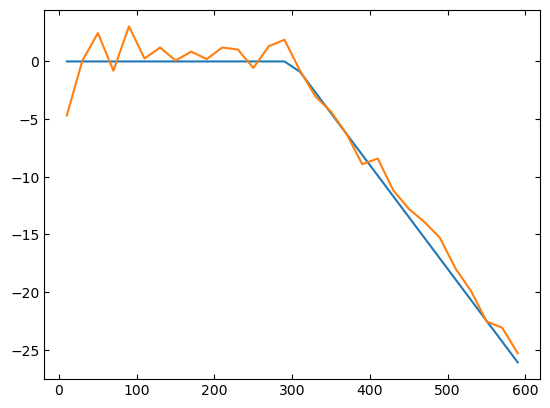

In [41]:
plt.plot(true_["RAD(arcs)"],true_["VRAD(km/s)"])
plt.plot(recorver["RAD(arcs)"],recorver["VRAD(km/s)"])


/tmp/ipykernel_599753/1942610964.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


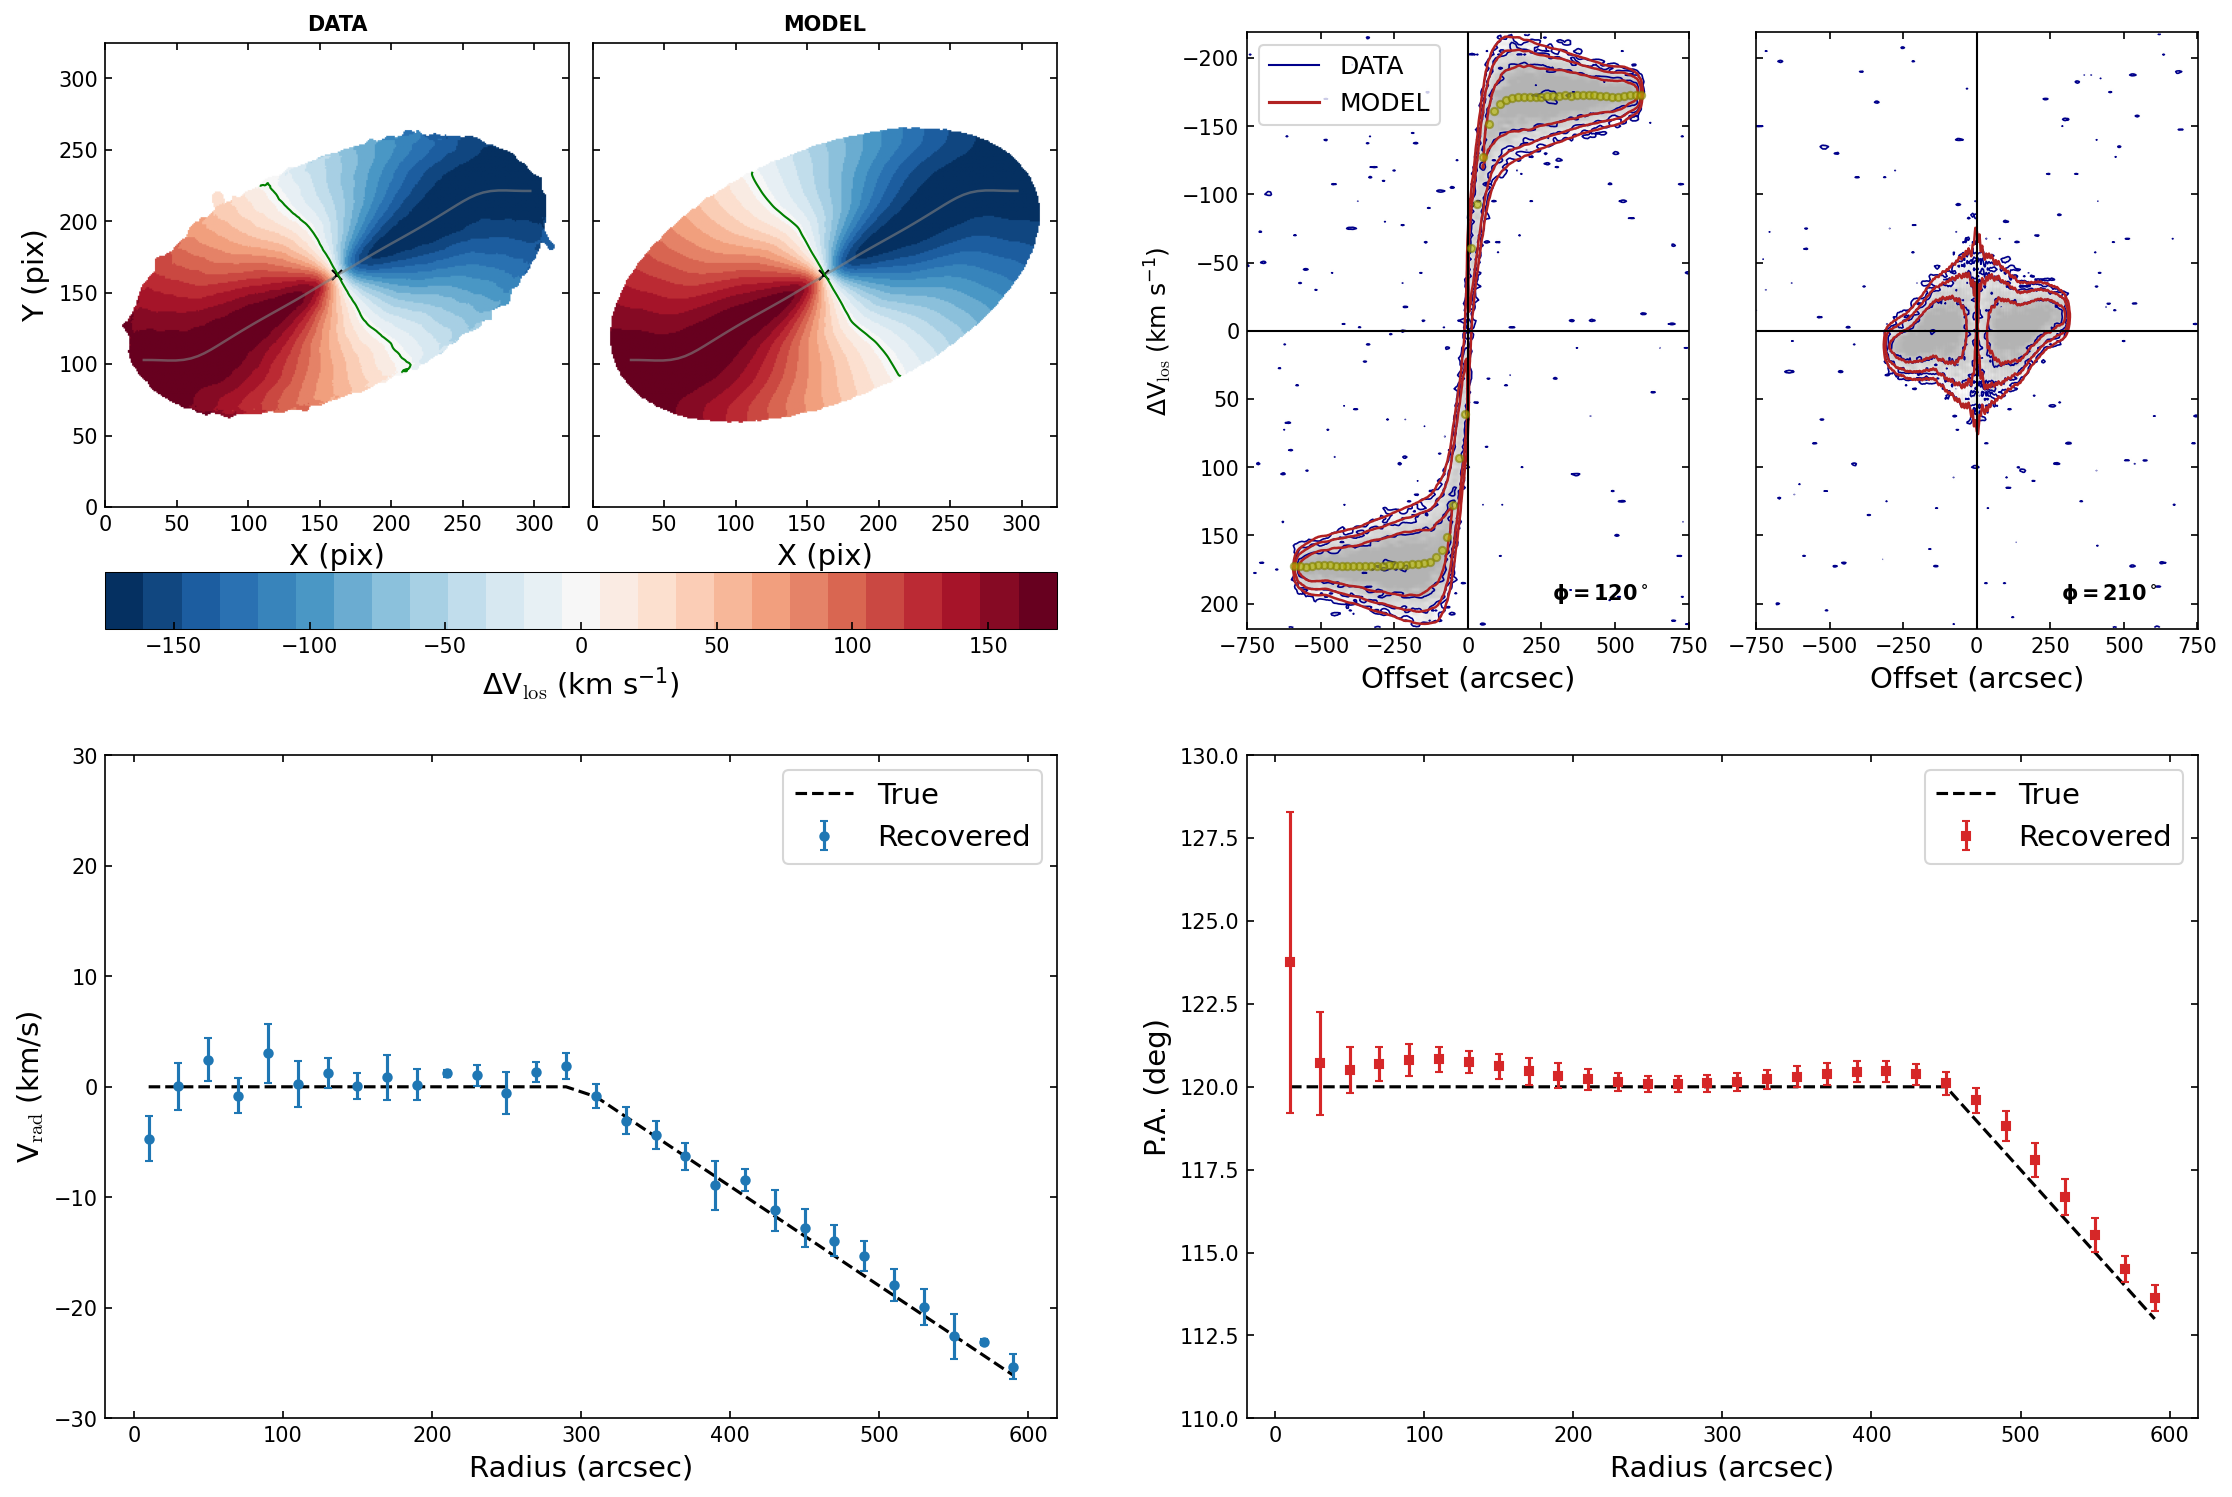

In [43]:
import numpy as np
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec
from astropy.io import fits
from astropy.visualization import PowerStretch, ImageNormalize

# --- 1. 全局样式设置 ---
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
mpl.rcParams['contour.negative_linestyle'] = 'solid' 
plt.rc('font', family='sans-serif', size=10)
params = {'text.usetex': False, 'mathtext.fontset': 'cm', 'mathtext.default': 'regular'}
plt.rcParams.update(params)

# --- 2. 路径与数据读取 ---
RING_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/"
RING_MODEL1123 = RING_BASE + "model1123/"
INITIAL_1123 = "/net/dataserver3/data/users/linn/para_initial/test_more_model/model1123/"
galaxy = "ring_v200_R50_PAk0.05_TP450_VRk0.09_TP300_INC60"
outfolder = RING_MODEL1123 + galaxy + "/second_step_check_sinw/"
gname = 'SNR10Res10mod'

recorver = pd.read_csv(outfolder + "rings_final2.txt", delimiter=r"\s+")
true_ = pd.read_csv(INITIAL_1123 + galaxy + ".txt", delimiter=r"\s+")
error_ = pd.read_csv(RING_MODEL1123 + galaxy + "/bootstrap_error.txt", delimiter=r"\s+")

# 读取文件用于 Top-Left
xmin, xmax, ymin, ymax = 238, 562, 238, 562
f1 = fits.open(outfolder + '/maps/' + gname + '_1mom.fits')
mom1 = f1[0].data[ymin:ymax+1, xmin:xmax+1]
mod_file_list = sorted([f for f in os.listdir(outfolder + '/maps/') if '1mom.fits' in f and ('azim' in f or 'local' in f)])
mom1_mod = fits.open(outfolder + '/maps/' + mod_file_list[0])[0].data[ymin:ymax+1, xmin:xmax+1]

rad, inc, pa, xpos, ypos, vsys = np.genfromtxt(
    outfolder + "rings_final2.txt",
    usecols=(1,4,5,9,10,11),
    unpack=True
)

xcen_m, ycen_m, inc_m, pa_m, vsys_m = np.nanmean((xpos, ypos, inc, pa, vsys), axis=1)
xcen = xcen_m - xmin
ycen = ycen_m - ymin

# --- 3. 开始绘图 ---
fig = plt.figure(figsize=(18, 12), dpi=150)
gs = GridSpec(2, 2, figure=fig,  wspace=0.2,height_ratios=[0.9, 1])

# ==========================================
# 【左上：速度图对比】
# ==========================================
# 将左上格子 (gs[0, 0]) 垂直切分：上方 85% 给图，下方 5% 给色标，中间留空
gs_tl_main = gs[0, 0].subgridspec(2, 1, height_ratios=[0.85, 0.1])
gs_tl_maps = gs_tl_main[0, 0].subgridspec(1, 2, wspace=0.05)

from astropy.visualization import PercentileInterval
from copy import copy

cmap_vel = plt.get_cmap('RdBu_r', 25)

# 用 DATA 来决定对称色标范围（推荐）
data_for_norm = mom1 - vsys_m

interval = PercentileInterval(99.5)
vmin, vmax = interval.get_limits(data_for_norm)
vabs = max(abs(vmin), abs(vmax))

norm_m = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)

# 复制 cmap 并设置 NaN 为白色（和你大图一致）
cmap_vel = copy(cmap_vel)
cmap_vel.set_bad('w', 1.)

# 数据列表：[DATA, MODEL]
map_list = [mom1 - vsys_m, mom1_mod - vsys_m]
titles = ['DATA', 'MODEL']

for j, d in enumerate(map_list):
    ax = fig.add_subplot(gs_tl_maps[0, j])
    ax.imshow(d, origin='lower', cmap=cmap_vel, norm=norm_m, extent=[0, xmax-xmin, 0, ymax-ymin], aspect='equal')
    ax.plot(xcen, ycen, 'x', color='black', markersize=5)
    ax.contour(d, levels=[0], colors='green', origin='lower', linewidths=1)
    ax.set_xlabel('X (pix)')
    ax.set_title(titles[j], fontsize=10, fontweight='bold')
    
    if j == 0: 
        ax.set_ylabel('Y (pix)')
    else: 
        ax.set_yticklabels([])
    # ===== 加 global major axis =====
    x_grid = np.linspace(0, xmax-xmin, 500)
    
    # major axis: PA - 90°
    # y_major = np.tan(np.radians(pa_m - 90)) * (x_grid - xcen) + ycen
    # ax.plot(x_grid, y_major, '-', color='grey', lw=1.5, alpha=0.7)
    if len(rad_pix) > 5:
        x_p = rad_pix * np.cos(np.radians(pa - 90))
        y_p = rad_pix * np.sin(np.radians(pa - 90))
        ax.plot(xcen - x_p, ycen - y_p, '-', color='grey', lw=1.2, alpha=0.6)
        ax.plot(xcen + x_p, ycen + y_p, '-', color='grey', lw=1.2, alpha=0.6)
        

# 在左上格子的底部绘制横跨两图的色标
ax_cb_tl = fig.add_subplot(gs_tl_main[1, 0])
cb_tl = ColorbarBase(ax_cb_tl, orientation='horizontal', cmap=cmap_vel, norm=norm_m)
cb_tl.set_label(r'$\Delta V_{\mathrm{los}}$ (km s$^{-1}$)', fontsize=14)
cb_tl.outline.set_linewidth(0.5)

# 顶部标题
#fig.text(0.13, 0.9, r'$\Delta PA=7.5\ deg\ \ \Delta Vrad=-27\ km/s$', fontsize=14, fontweight='bold')

# ==========================================
# 【右上：PV 图对比】修正部分
# ==========================================
# 在右上格子里创建一个 1x2 的子布局
gs_tr = gs[0, 1].subgridspec(1, 2, wspace=0.15)

# PV 数据准备
zmin, zmax = 13, 187
image_maj = fits.open(outfolder + 'pvs/' + gname + '_pv_a.fits')
image_min = fits.open(outfolder + 'pvs/' + gname + '_pv_b.fits')
# 自动寻找对应的模型PV文件
mod_pv_a = sorted([f for f in os.listdir(outfolder + 'pvs/') if 'pv_a_azim.fits' in f or 'pv_a_local.fits' in f])[0]
mod_pv_b = sorted([f for f in os.listdir(outfolder + 'pvs/') if 'pv_b_azim.fits' in f or 'pv_b_local.fits' in f])[0]
im_mod_maj = fits.open(outfolder + 'pvs/' + mod_pv_a)
im_mod_min = fits.open(outfolder + 'pvs/' + mod_pv_b)

# 坐标计算 (简化用于展示)
head = image_maj[0].header
crpix, cdelt, crval = head['CRPIX1'], head['CDELT1'], head['CRVAL1']
xminpv, xmaxpv = int(crpix - 1 - 162), int(crpix - 1 + 162)
xmin_wcs = ((xminpv + 1 - 0.5 - crpix) * cdelt + crval) * 3600
xmax_wcs = ((xmaxpv + 1 + 0.5 - crpix) * cdelt + crval) * 3600
zmin_wcs, zmax_wcs = 255.25, -182.25
ext_pv = [xmin_wcs, xmax_wcs, zmin_wcs - vsys_m, zmax_wcs - vsys_m]

# 统一归一化
cont = 0.000675824
v_levels = np.array([1, 2, 4, 8, 16, 32, 64]) * cont
norm_pv = ImageNormalize(vmin=cont, vmax=image_maj[0].data.max()*0.7, stretch=PowerStretch(0.5))

# 绘制
pv_datas = [image_maj[0].data[zmin:zmax+1, xminpv:xmaxpv+1], image_min[0].data[zmin:zmax+1, xminpv:xmaxpv+1]]
pv_mods = [im_mod_maj[0].data[zmin:zmax+1, xminpv:xmaxpv+1], im_mod_min[0].data[zmin:zmax+1, xminpv:xmaxpv+1]]
phi_labels = [r'$\phi = 120^\circ$', r'$\phi = 210^\circ$']

for i in range(2):
    ax = fig.add_subplot(gs_tr[0, i])
    ax.imshow(pv_datas[i], origin='lower', cmap='Greys', norm=norm_pv, extent=ext_pv, aspect='auto', alpha=0.3)
    ax.contour(pv_datas[i], v_levels, origin='lower', linewidths=0.8, colors='#00008B', extent=ext_pv)
    ax.contour(pv_mods[i], v_levels, origin='lower', linewidths=1.2, colors='#B22222', extent=ext_pv)
    ax.axhline(y=0, color='black', lw=1); ax.axvline(x=0, color='black', lw=1)
    ax.set_xlabel('Offset (arcsec)')
    ax.text(0.8, 0.05, phi_labels[i], transform=ax.transAxes, fontsize=10, fontweight='bold', ha='center')
    if i == 0: 
            ax.set_ylabel(r'$\Delta V_{\mathrm{los}}$ (km s$^{-1}$)', fontsize=labsize)
            # 叠加旋转曲线点
            ax.plot(radius_pts, vlos_pts, 'y.', markersize=7, markeredgecolor='olive', alpha=0.6)
            # 添加图例
            from matplotlib.lines import Line2D
            legend_elements = [Line2D([0], [0], color='#00008B', lw=1, label='DATA'),
                               Line2D([0], [0], color='#B22222', lw=1.5, label='MODEL')]
            ax.legend(handles=legend_elements, loc='upper left', frameon=True, fontsize=12)
    else:
            ax.set_yticklabels([]) # 隐藏右图 Y 轴标签
           
# ==========================================
# 【左下：VRAD 误差图】
# ==========================================
ax_vrad = fig.add_subplot(gs[1, 0])
ax_vrad.plot(true_["RAD(arcs)"], true_["VRAD(km/s)"], 'k--', label='True')
ax_vrad.errorbar(recorver["RAD(arcs)"], recorver["VRAD(km/s)"], yerr=error_["VRADerror(km/s)"], fmt='o', color='tab:blue', label='Recovered', markersize=4, capsize=2)
ax_vrad.set_xlabel('Radius (arcsec)')
ax_vrad.set_ylabel(r'$V_{\mathrm{rad}}$ (km/s)')
ax_vrad.legend(fontsize=14)
ax_vrad.set_ylim(-30, 30)
# ==========================================
# 【右下：PA 误差图】
# ==========================================
ax_pa = fig.add_subplot(gs[1, 1])
ax_pa.plot(true_["RAD(arcs)"], true_["P.A.(deg)"], 'k--', label='True')
ax_pa.errorbar(recorver["RAD(arcs)"], recorver["P.A.(deg)"], yerr=error_["P.A.error(deg)"], fmt='s', color='tab:red', label='Recovered', markersize=4, capsize=2)
ax_pa.set_xlabel('Radius (arcsec)')
ax_pa.set_ylabel('P.A. (deg)')
ax_pa.legend(fontsize=14)
ax_pa.set_ylim(120-10, 120+10)
#plt.savefig("single_galaxy_error.pdf")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3194682/2517112255.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


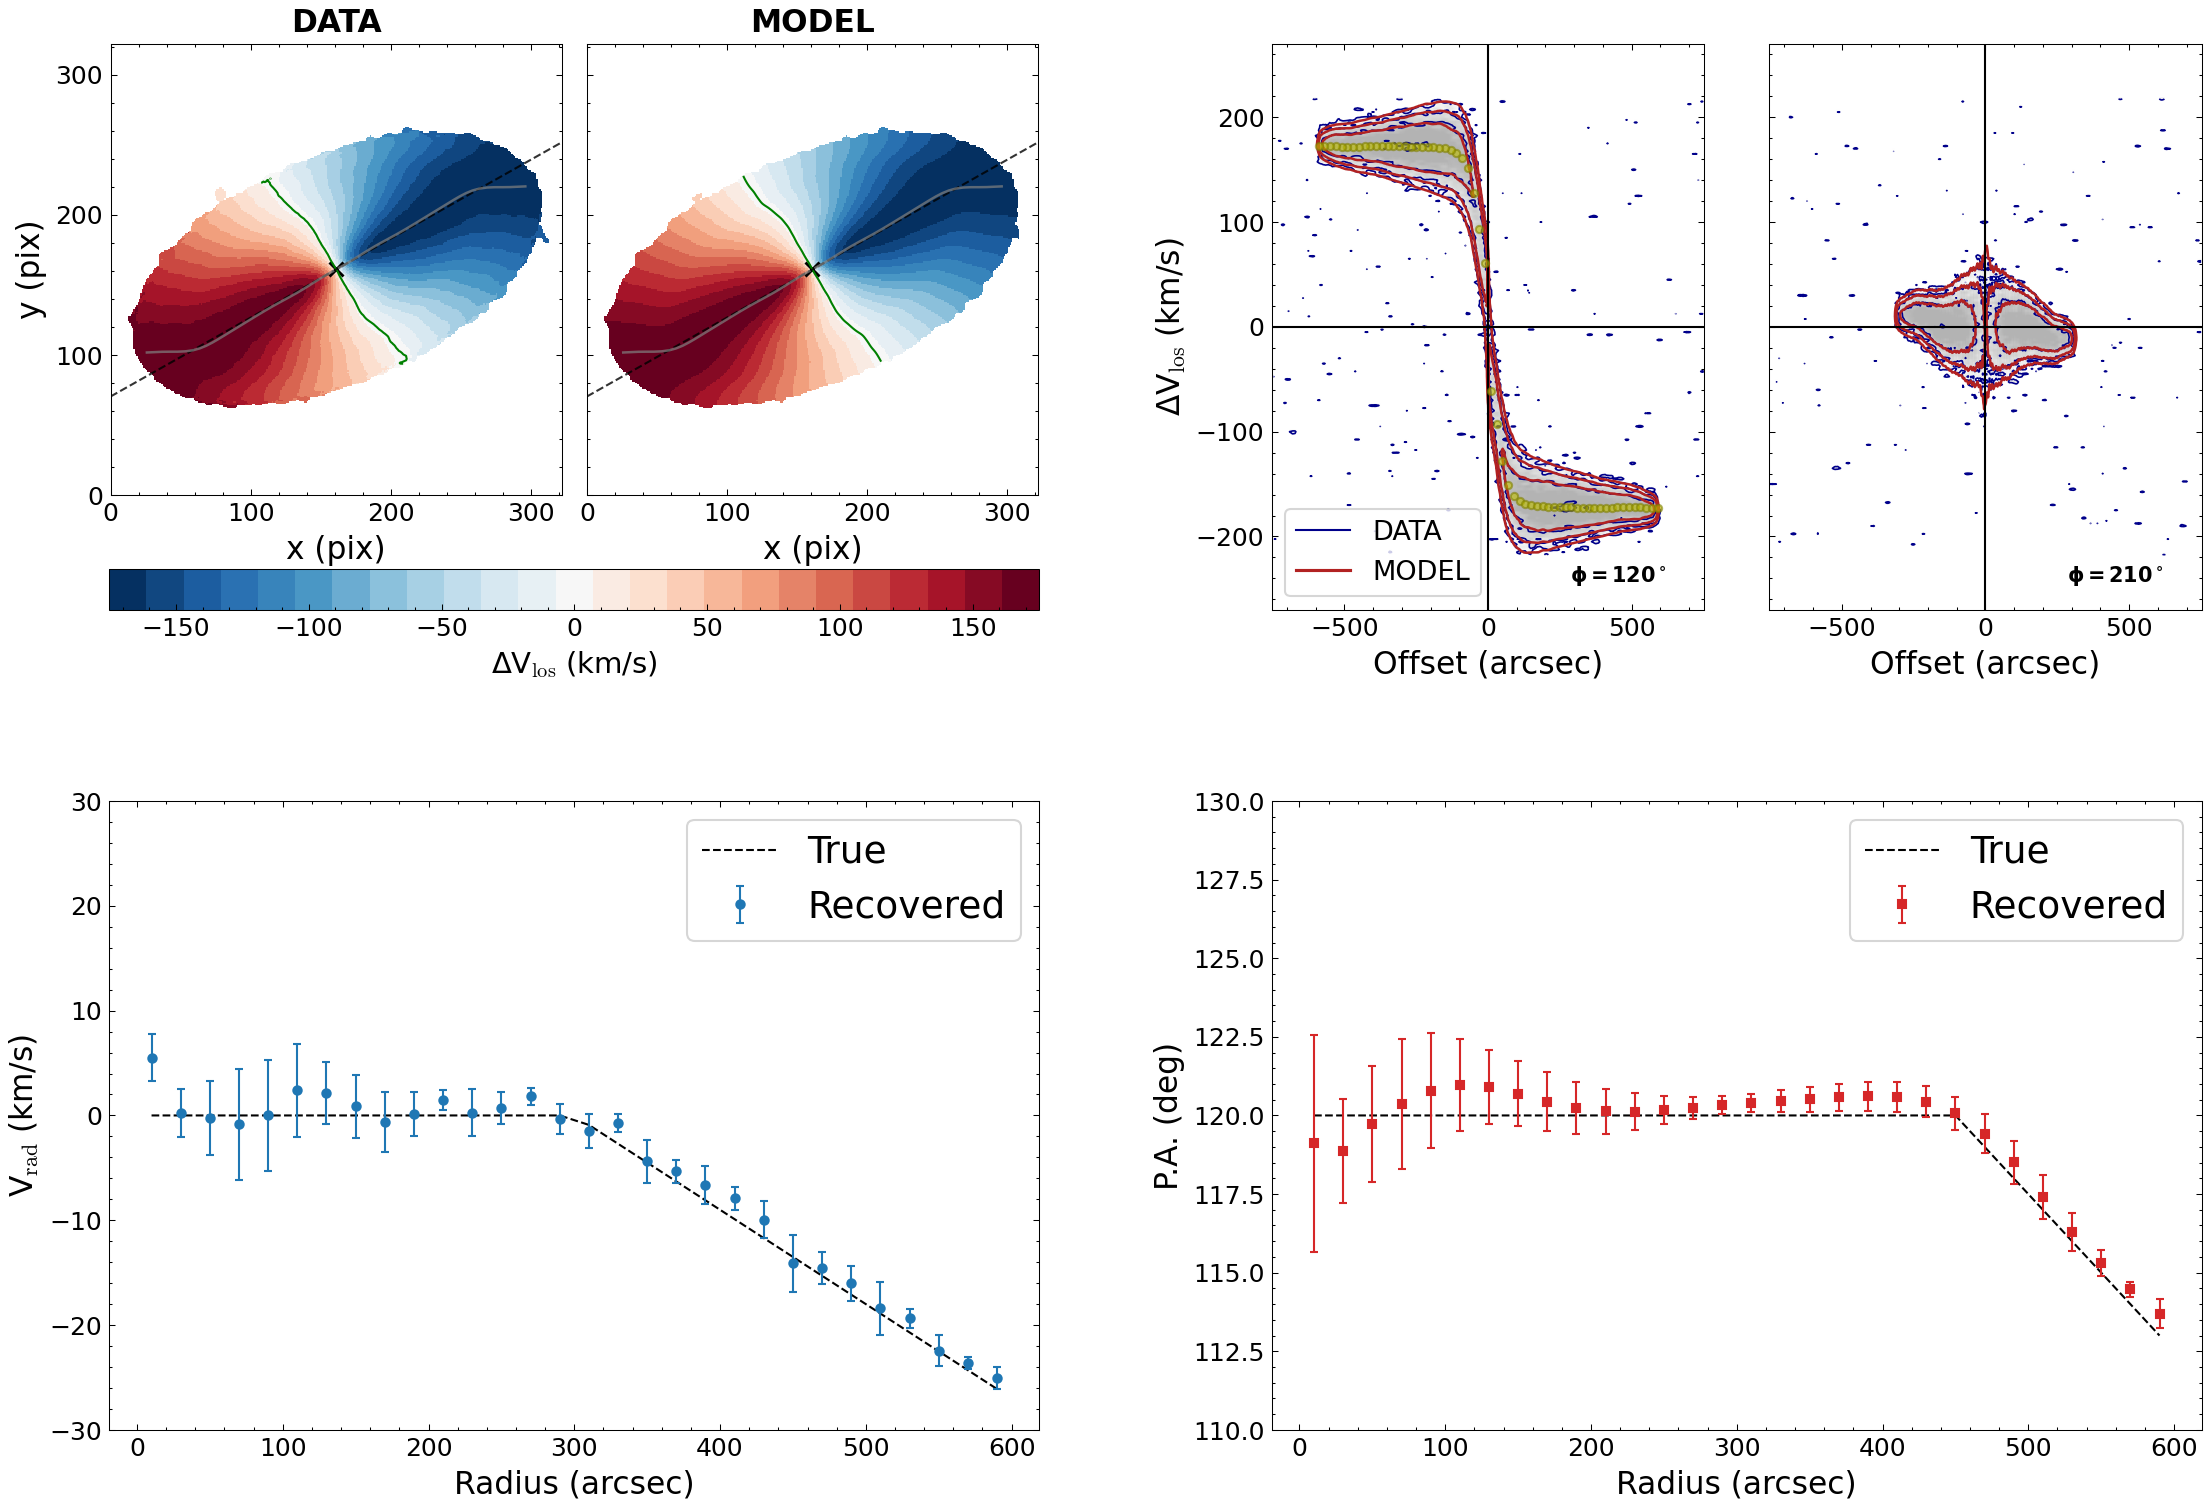

In [8]:
import numpy as np
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec
from astropy.io import fits
from astropy.visualization import PercentileInterval, PowerStretch, ImageNormalize
from copy import copy
from matplotlib.lines import Line2D
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
# ============================================================
# 1. 全局样式
# ============================================================
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
mpl.rcParams['contour.negative_linestyle'] = 'solid'
plt.rc('font', family='sans-serif', size=10)

params = {
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'mathtext.default': 'regular'
}
plt.rcParams.update(params)


# ============================================================
# 2. 路径与数据
# ============================================================
RING_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/"
RING_MODEL1123 = RING_BASE + "model1123_processed_60/"
INITIAL_1123 = "/net/dataserver3/data/users/linn/para_initial/test_more_model/model1123/"

galaxy = "ring_v200_R50_PAk0.05_TP450_VRk0.09_TP300_INC60"
outfolder = RING_MODEL1123 + galaxy + "/second_step_check_sinw/"
gname = "SNR10Res10mod"

recorver = pd.read_csv(outfolder + "rings_final2.txt", delimiter=r"\s+")
true_ = pd.read_csv(INITIAL_1123 + galaxy + ".txt", delimiter=r"\s+")
error_ = pd.read_csv(RING_MODEL1123 + galaxy + "/bootstrap_error.txt", delimiter=r"\s+")

# ============================================================
# 3. 读取 ring 参数
# ============================================================
rad, inc, pa, xpos, ypos, vsys = np.genfromtxt(
    outfolder + "rings_final2.txt",
    usecols=(1, 4, 5, 9, 10, 11),
    unpack=True
)

xcen_m, ycen_m, inc_m, pa_m, vsys_m = np.nanmean(
    (xpos, ypos, inc, pa, vsys),
    axis=1
)

# 和你的 map 脚本保持一致
xmin, xmax = 39, 361
ymin, ymax = 39, 361

xcen = xcen_m - xmin
ycen = ycen_m - ymin

# 你的模型里 1 pix = 4 arcsec
rad_pix = rad / 4.0

try:
    nr = len(rad_pix)
except TypeError:
    nr = 1

# ============================================================
# 4. 读取 moment map
# ============================================================
f1 = fits.open(outfolder + "/maps/" + gname + "_1mom.fits")
mom1 = f1[0].data[ymin:ymax + 1, xmin:xmax + 1]

mod_file_list = sorted([
    f for f in os.listdir(outfolder + "/maps/")
    if "1mom.fits" in f and ("azim" in f or "local" in f)
])

mom1_mod = fits.open(outfolder + "/maps/" + mod_file_list[0])[0].data[
    ymin:ymax + 1, xmin:xmax + 1
]

maskmap = np.copy(mom1)
maskmap[np.isfinite(mom1)] = 1

ext_map = [0, xmax - xmin, 0, ymax - ymin]

# ============================================================
# 5. 开始画图
# ============================================================
fig = plt.figure(figsize=(18, 12), dpi=150)
gs = GridSpec(
    2, 2,
    figure=fig,
    wspace=0.25,
    hspace=0.32,
    height_ratios=[0.9, 1.0]
)

# ============================================================
# 左上：DATA / MODEL velocity map
# ============================================================
gs_tl_main = gs[0, 0].subgridspec(
    2, 1,
    height_ratios=[0.88, 0.08],
    hspace=0.3
)
gs_tl_maps = gs_tl_main[0, 0].subgridspec(1, 2, wspace=0.05)

cmap_vel = copy(plt.get_cmap("RdBu_r", 25))
cmap_vel.set_bad("w", 1.0)

data_for_norm = mom1 - vsys_m
interval = PercentileInterval(99.5)
vmin, vmax = interval.get_limits(data_for_norm)
vabs = max(abs(vmin), abs(vmax))

norm_m = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)

map_list = [
    mom1 - vsys_m,
    mom1_mod - vsys_m
]
titles = ["DATA", "MODEL"]

# global major axis from mean PA
x_major = np.arange(0, xmax - xmin, 0.1)
y_major = np.tan(np.radians(pa_m - 90.0)) * (x_major - xcen) + ycen

for j, d in enumerate(map_list):
    ax = fig.add_subplot(gs_tl_maps[0, j])

    ax.imshow(
        d * maskmap,
        origin="lower",
        cmap=cmap_vel,
        norm=norm_m,
        extent=ext_map,
        aspect="equal",
        interpolation="nearest"
    )

    ax.plot(xcen, ycen, "x", color="black", markersize=7, mew=1.4)

    # green zero-velocity contour
    ax.contour(
        d * maskmap,
        levels=[0],
        colors="green",
        origin="lower",
        extent=ext_map,
        linewidths=1.0
    )

    # mean major axis
    ax.plot(x_major, y_major, "--", color="k", linewidth=1.0, alpha=0.8)

    # warped PA trace, same logic as map script
    if nr > 5 and not np.all(np.diff(pa) == 0):
        x_pix = rad_pix * np.cos(np.radians(pa - 90.0))
        y_pix = rad_pix * np.sin(np.radians(pa - 90.0))

        ax.plot(
            xcen - x_pix, ycen - y_pix,
            "-",
            color="grey",
            lw=1.2,
            alpha=0.7
        )
        ax.plot(
            xcen + x_pix, ycen + y_pix,
            "-",
            color="grey",
            lw=1.2,
            alpha=0.7
        )

    # outer ellipse
    if j != 2 and nr > 3:
        axmaj = rad_pix[-1]
        axmin = axmaj * np.cos(np.radians(inc_m))
        posa = np.radians(pa_m - 90.0)

        t = np.linspace(0, 2 * np.pi, 200)
        xt = (
            xcen
            + axmaj * np.cos(posa) * np.cos(t)
            - axmin * np.sin(posa) * np.sin(t)
        )
        yt = (
            ycen
            + axmaj * np.sin(posa) * np.cos(t)
            + axmin * np.cos(posa) * np.sin(t)
        )
        #ax.plot(xt, yt, "-", color="k", lw=0.8, alpha=0.8)

    ax.set_xlim(ext_map[0], ext_map[1])
    ax.set_ylim(ext_map[2], ext_map[3])
    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.yaxis.set_major_locator(MultipleLocator(100))    

    ax.set_xlabel("x (pix)")
    ax.set_title(titles[j], fontsize=15, fontweight="bold")

    if j == 0:
        ax.set_ylabel("y (pix)")
    else:
        ax.set_yticklabels([])

# colorbar for maps
ax_cb_tl = fig.add_subplot(gs_tl_main[1, 0])
cb_tl = ColorbarBase(
    ax_cb_tl,
    orientation="horizontal",
    cmap=cmap_vel,
    norm=norm_m
)
cb_tl.set_label(r"$\Delta V_{\mathrm{los}}$ (km/s)", fontsize=14)
cb_tl.outline.set_linewidth(0.5)

# ============================================================
# 右上：PV diagrams
# ============================================================
gs_tr = gs[0, 1].subgridspec(1, 2, wspace=0.15)

# PV 数据准备
zmin, zmax = 13, 187
image_maj = fits.open(outfolder + 'pvs/' + gname + '_pv_a.fits')
image_min = fits.open(outfolder + 'pvs/' + gname + '_pv_b.fits')
# 自动寻找对应的模型PV文件
mod_pv_a = sorted([f for f in os.listdir(outfolder + 'pvs/') if 'pv_a_azim.fits' in f or 'pv_a_local.fits' in f])[0]
mod_pv_b = sorted([f for f in os.listdir(outfolder + 'pvs/') if 'pv_b_azim.fits' in f or 'pv_b_local.fits' in f])[0]
im_mod_maj = fits.open(outfolder + 'pvs/' + mod_pv_a)
im_mod_min = fits.open(outfolder + 'pvs/' + mod_pv_b)

# 坐标计算 (简化用于展示)
head = image_maj[0].header
crpix, cdelt, crval = head['CRPIX1'], head['CDELT1'], head['CRVAL1']
xminpv, xmaxpv = int(crpix - 1 - 162), int(crpix - 1 + 162)
xmin_wcs = ((xminpv + 1 - 0.5 - crpix) * cdelt + crval) * 3600
xmax_wcs = ((xmaxpv + 1 + 0.5 - crpix) * cdelt + crval) * 3600
zmin_wcs, zmax_wcs = 255.25, -182.25
ext_pv = [xmin_wcs, xmax_wcs, zmin_wcs - vsys_m, zmax_wcs - vsys_m]

# 统一归一化
cont = 0.000675824
v_levels = np.array([1, 2, 4, 8, 16, 32, 64]) * cont
norm_pv = ImageNormalize(vmin=cont, vmax=image_maj[0].data.max()*0.7, stretch=PowerStretch(0.5))

# 绘制
pv_datas = [image_maj[0].data[zmin:zmax+1, xminpv:xmaxpv+1], image_min[0].data[zmin:zmax+1, xminpv:xmaxpv+1]]
pv_mods = [im_mod_maj[0].data[zmin:zmax+1, xminpv:xmaxpv+1], im_mod_min[0].data[zmin:zmax+1, xminpv:xmaxpv+1]]
phi_labels = [r'$\phi = 120^\circ$', r'$\phi = 210^\circ$']

for i in range(2):
    ax = fig.add_subplot(gs_tr[0, i])
    ax.imshow(pv_datas[i], origin='lower', cmap='Greys', norm=norm_pv, extent=ext_pv, aspect='auto', alpha=0.3)
    ax.contour(pv_datas[i], v_levels, origin='lower', linewidths=0.8, colors='#00008B', extent=ext_pv)
    ax.contour(pv_mods[i], v_levels, origin='lower', linewidths=1.2, colors='#B22222', extent=ext_pv)
    ax.axhline(y=0, color='black', lw=1); ax.axvline(x=0, color='black', lw=1)
    ax.set_ylim(-270,270)
    ax.set_xlabel('Offset (arcsec)')
    ax.text(0.8, 0.05, phi_labels[i], transform=ax.transAxes, fontsize=10, fontweight='bold', ha='center')
    if i == 0: 
            ax.set_ylabel(r'$\Delta V_{\mathrm{los}}$ (km/s)')
            # 叠加旋转曲线点
            ax.plot(radius_pts, vlos_pts, 'y.', markersize=7, markeredgecolor='olive', alpha=0.6)
            # 添加图例
            from matplotlib.lines import Line2D
            legend_elements = [Line2D([0], [0], color='#00008B', lw=1, label='DATA'),
                               Line2D([0], [0], color='#B22222', lw=1.5, label='MODEL')]
            ax.legend(handles=legend_elements, loc='lower left', frameon=True, fontsize=13)
    else:
            ax.set_yticklabels([]) # 隐藏右图 Y 轴标签
    from matplotlib.ticker import MultipleLocator
    

# ============================================================
# 左下：VRAD
# ============================================================
ax_vrad = fig.add_subplot(gs[1, 0])

ax_vrad.plot(
    true_["RAD(arcs)"],
    true_["VRAD(km/s)"],
    "k--",
    label="True"
)

ax_vrad.errorbar(
    recorver["RAD(arcs)"],
    recorver["VRAD(km/s)"],
    yerr=error_["VRADerror(km/s)"],
    fmt="o",
    color="tab:blue",
    label="Recovered",
    markersize=4,
    capsize=2
)

ax_vrad.set_xlabel("Radius (arcsec)")
ax_vrad.set_ylabel(r"$V_{\mathrm{rad}}$ (km/s)")
ax_vrad.legend(fontsize=18,frameon=True)
ax_vrad.set_ylim(-30, 30)

# ============================================================
# 右下：PA
# ============================================================
ax_pa = fig.add_subplot(gs[1, 1])

ax_pa.plot(
    true_["RAD(arcs)"],
    true_["P.A.(deg)"],
    "k--",
    label="True"
)

ax_pa.errorbar(
    recorver["RAD(arcs)"],
    recorver["P.A.(deg)"],
    yerr=error_["P.A.error(deg)"],
    fmt="s",
    color="tab:red",
    label="Recovered",
    markersize=4,
    capsize=2
)

ax_pa.set_xlabel("Radius (arcsec)")
ax_pa.set_ylabel("P.A. (deg)")
ax_pa.legend(fontsize=18,frameon=True)
ax_pa.set_ylim(120 - 10, 120 + 10)

plt.tight_layout()

plt.savefig("single_galaxy_error_with_maps_pv_2.pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_3194682/3078502845.py:343: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


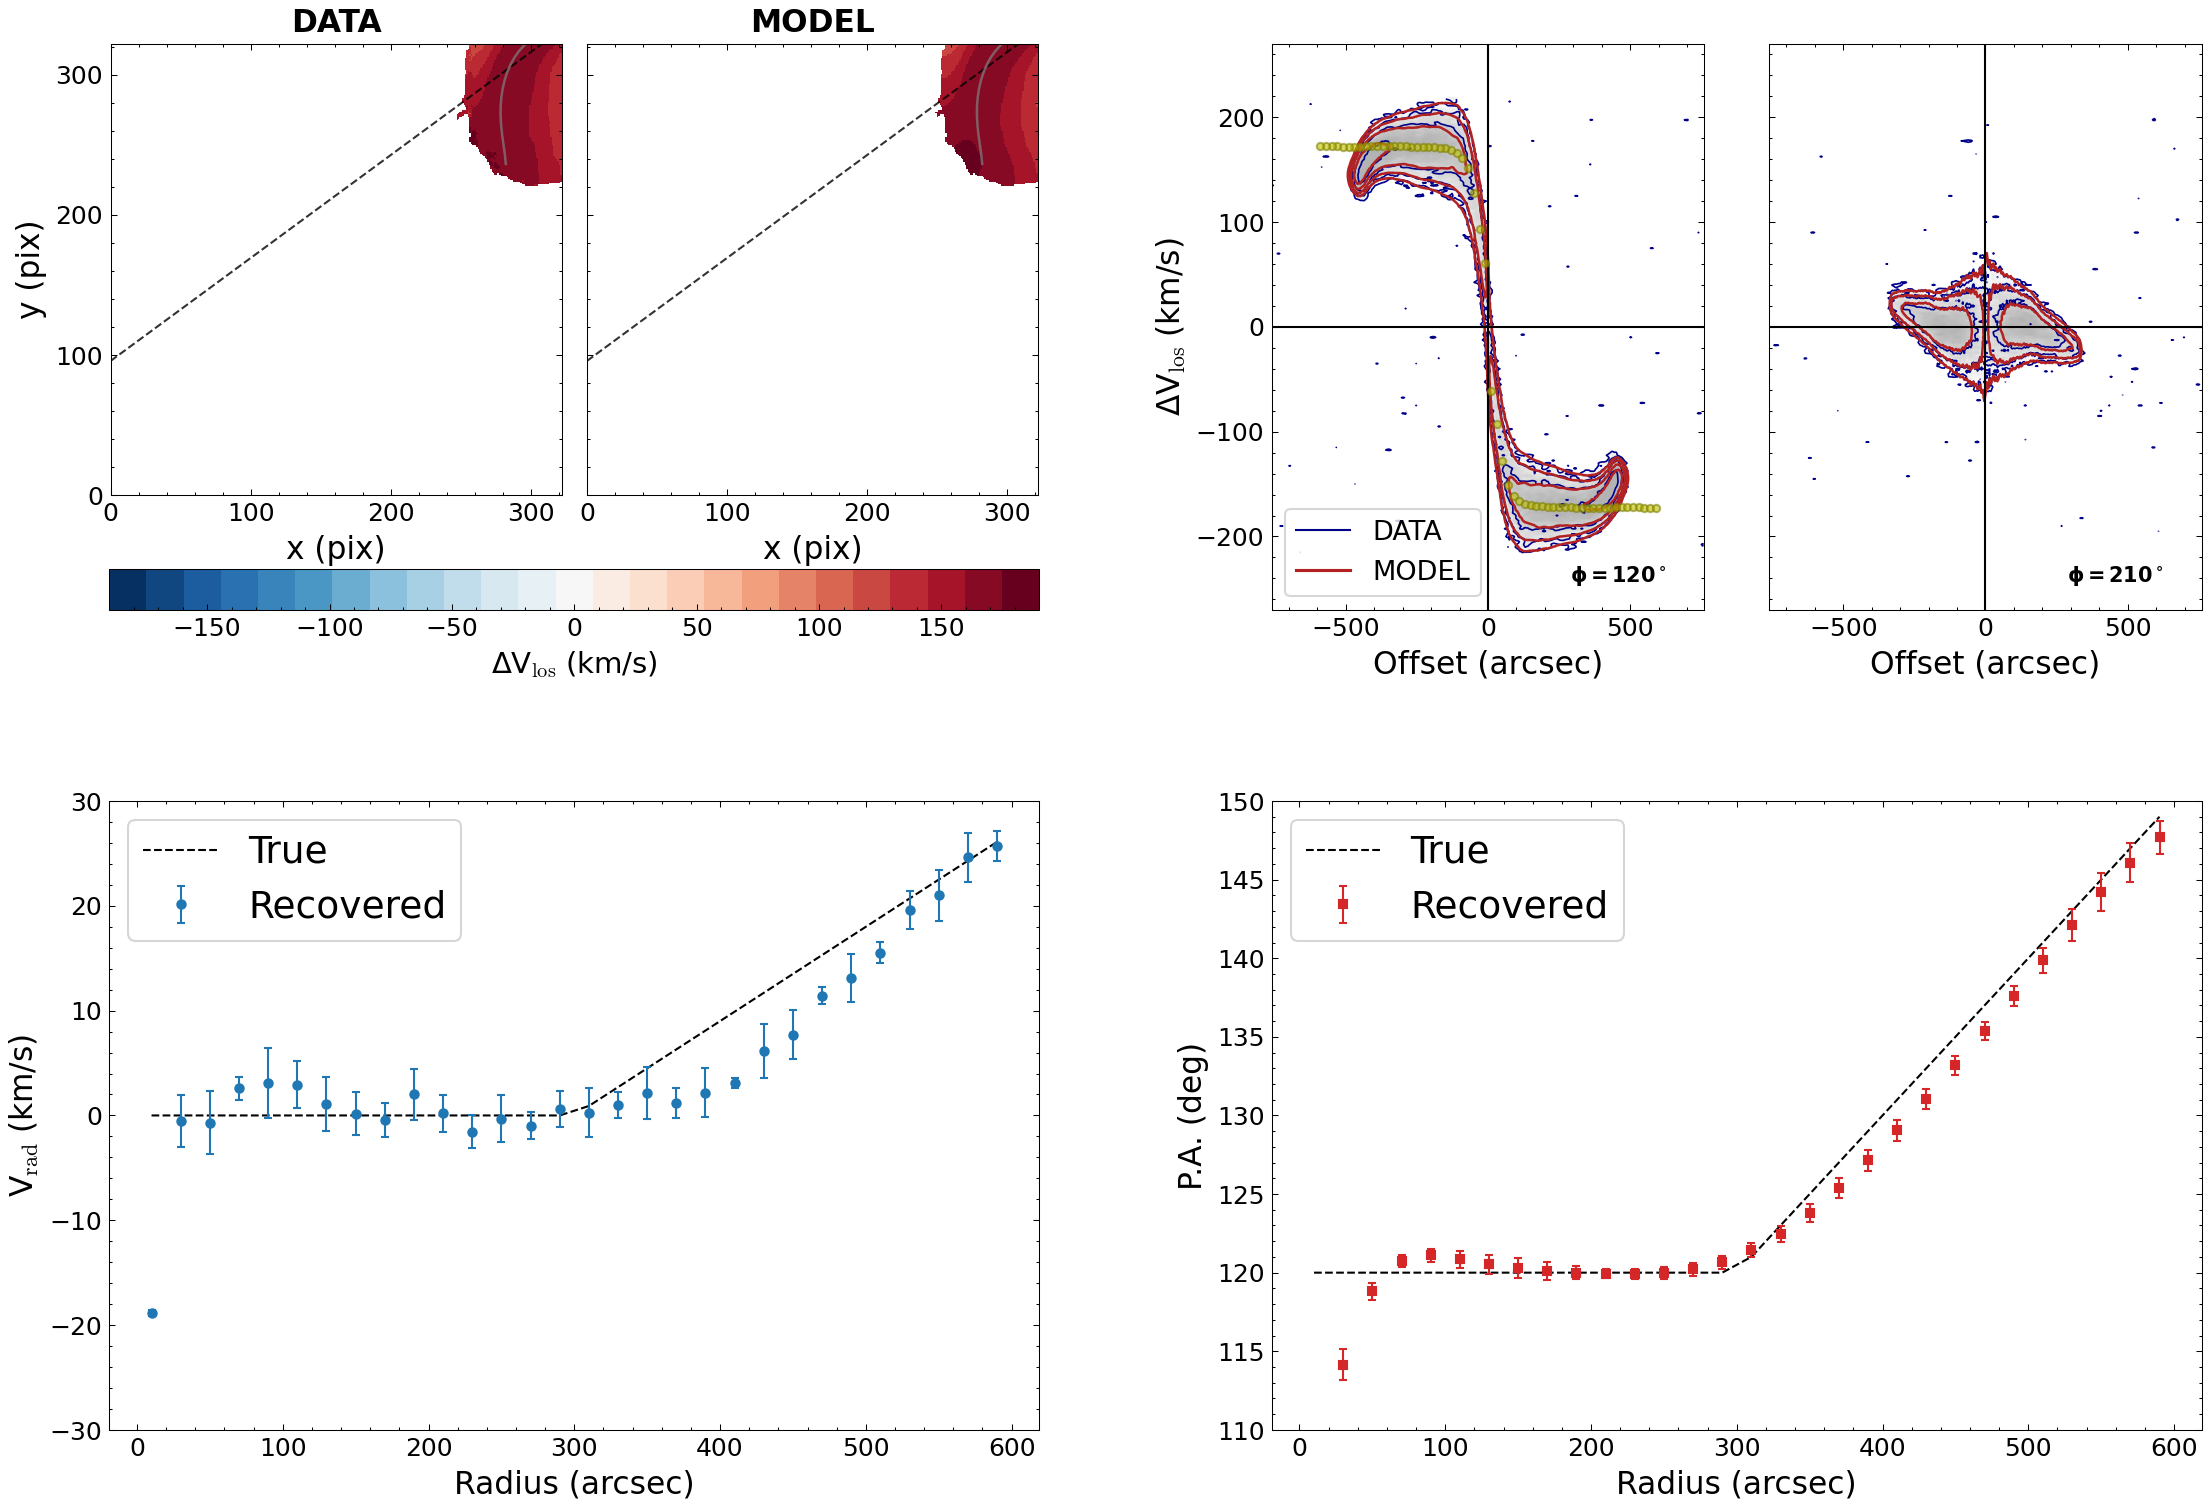

In [10]:
import numpy as np
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec
from astropy.io import fits
from astropy.visualization import PercentileInterval, PowerStretch, ImageNormalize
from copy import copy
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
# ============================================================
# 1. 全局样式
# ============================================================
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
mpl.rcParams['contour.negative_linestyle'] = 'solid'
plt.rc('font', family='sans-serif', size=10)

params = {
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'mathtext.default': 'regular'
}
plt.rcParams.update(params)


# ============================================================
# 2. 路径与数据
# ============================================================
RING_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/"
RING_MODEL1123 = RING_BASE + "model1123/"
INITIAL_1123 = "/net/dataserver3/data/users/linn/para_initial/test_more_model/model1123/"

galaxy = "ring_v200_R50_PAk-0.1_TP300_VRk-0.09_TP300_INC60"
outfolder = RING_MODEL1123 + galaxy + "/second_step_check_sinw/"
gname = "SNR10Res10mod"

recorver = pd.read_csv(outfolder + "rings_final2.txt", delimiter=r"\s+")
true_ = pd.read_csv(INITIAL_1123 + galaxy + ".txt", delimiter=r"\s+")
error_ = pd.read_csv(RING_MODEL1123 + galaxy + "/bootstrap_error.txt", delimiter=r"\s+")

# ============================================================
# 3. 读取 ring 参数
# ============================================================
rad, inc, pa, xpos, ypos, vsys = np.genfromtxt(
    outfolder + "rings_final2.txt",
    usecols=(1, 4, 5, 9, 10, 11),
    unpack=True
)

xcen_m, ycen_m, inc_m, pa_m, vsys_m = np.nanmean(
    (xpos, ypos, inc, pa, vsys),
    axis=1
)

# 和你的 map 脚本保持一致
xmin, xmax = 39, 361
ymin, ymax = 39, 361

xcen = xcen_m - xmin
ycen = ycen_m - ymin

# 你的模型里 1 pix = 4 arcsec
rad_pix = rad / 4.0

try:
    nr = len(rad_pix)
except TypeError:
    nr = 1

# ============================================================
# 4. 读取 moment map
# ============================================================
f1 = fits.open(outfolder + "/maps/" + gname + "_1mom.fits")
mom1 = f1[0].data[ymin:ymax + 1, xmin:xmax + 1]

mod_file_list = sorted([
    f for f in os.listdir(outfolder + "/maps/")
    if "1mom.fits" in f and ("azim" in f or "local" in f)
])

mom1_mod = fits.open(outfolder + "/maps/" + mod_file_list[0])[0].data[
    ymin:ymax + 1, xmin:xmax + 1
]

maskmap = np.copy(mom1)
maskmap[np.isfinite(mom1)] = 1

ext_map = [0, xmax - xmin, 0, ymax - ymin]

# ============================================================
# 5. 开始画图
# ============================================================
fig = plt.figure(figsize=(18, 12), dpi=150)
gs = GridSpec(
    2, 2,
    figure=fig,
    wspace=0.25,
    hspace=0.32,
    height_ratios=[0.9, 1.0]
)

# ============================================================
# 左上：DATA / MODEL velocity map
# ============================================================
gs_tl_main = gs[0, 0].subgridspec(
    2, 1,
    height_ratios=[0.88, 0.08],
    hspace=0.3
)
gs_tl_maps = gs_tl_main[0, 0].subgridspec(1, 2, wspace=0.05)

cmap_vel = copy(plt.get_cmap("RdBu_r", 25))
cmap_vel.set_bad("w", 1.0)

data_for_norm = mom1 - vsys_m
interval = PercentileInterval(99.5)
vmin, vmax = interval.get_limits(data_for_norm)
vabs = max(abs(vmin), abs(vmax))

norm_m = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)

map_list = [
    mom1 - vsys_m,
    mom1_mod - vsys_m
]
titles = ["DATA", "MODEL"]

# global major axis from mean PA
x_major = np.arange(0, xmax - xmin, 0.1)
y_major = np.tan(np.radians(pa_m - 90.0)) * (x_major - xcen) + ycen

for j, d in enumerate(map_list):
    ax = fig.add_subplot(gs_tl_maps[0, j])

    ax.imshow(
        d * maskmap,
        origin="lower",
        cmap=cmap_vel,
        norm=norm_m,
        extent=ext_map,
        aspect="equal",
        interpolation="nearest"
    )

    ax.plot(xcen, ycen, "x", color="black", markersize=7, mew=1.4)

    # green zero-velocity contour
    ax.contour(
        d * maskmap,
        levels=[0],
        colors="green",
        origin="lower",
        extent=ext_map,
        linewidths=1.0
    )

    # mean major axis
    ax.plot(x_major, y_major, "--", color="k", linewidth=1.0, alpha=0.8)

    # warped PA trace, same logic as map script
    if nr > 5 and not np.all(np.diff(pa) == 0):
        x_pix = rad_pix * np.cos(np.radians(pa - 90.0))
        y_pix = rad_pix * np.sin(np.radians(pa - 90.0))

        ax.plot(
            xcen - x_pix, ycen - y_pix,
            "-",
            color="grey",
            lw=1.2,
            alpha=0.7
        )
        ax.plot(
            xcen + x_pix, ycen + y_pix,
            "-",
            color="grey",
            lw=1.2,
            alpha=0.7
        )

    # outer ellipse
    if j != 2 and nr > 3:
        axmaj = rad_pix[-1]
        axmin = axmaj * np.cos(np.radians(inc_m))
        posa = np.radians(pa_m - 90.0)

        t = np.linspace(0, 2 * np.pi, 200)
        xt = (
            xcen
            + axmaj * np.cos(posa) * np.cos(t)
            - axmin * np.sin(posa) * np.sin(t)
        )
        yt = (
            ycen
            + axmaj * np.sin(posa) * np.cos(t)
            + axmin * np.cos(posa) * np.sin(t)
        )
        #ax.plot(xt, yt, "-", color="k", lw=0.8, alpha=0.8)

    ax.set_xlim(ext_map[0], ext_map[1])
    ax.set_ylim(ext_map[2], ext_map[3])
    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.yaxis.set_major_locator(MultipleLocator(100))    

    ax.set_xlabel("x (pix)")
    ax.set_title(titles[j], fontsize=15, fontweight="bold")

    if j == 0:
        ax.set_ylabel("y (pix)")
    else:
        ax.set_yticklabels([])

# colorbar for maps
ax_cb_tl = fig.add_subplot(gs_tl_main[1, 0])
cb_tl = ColorbarBase(
    ax_cb_tl,
    orientation="horizontal",
    cmap=cmap_vel,
    norm=norm_m
)
cb_tl.set_label(r"$\Delta V_{\mathrm{los}}$ (km/s)", fontsize=14)
cb_tl.outline.set_linewidth(0.5)

# ============================================================
# 右上：PV diagrams
# ============================================================
gs_tr = gs[0, 1].subgridspec(1, 2, wspace=0.15)

# PV 数据准备
zmin, zmax = 13, 187
image_maj = fits.open(outfolder + 'pvs/' + gname + '_pv_a.fits')
image_min = fits.open(outfolder + 'pvs/' + gname + '_pv_b.fits')
# 自动寻找对应的模型PV文件
mod_pv_a = sorted([f for f in os.listdir(outfolder + 'pvs/') if 'pv_a_azim.fits' in f or 'pv_a_local.fits' in f])[0]
mod_pv_b = sorted([f for f in os.listdir(outfolder + 'pvs/') if 'pv_b_azim.fits' in f or 'pv_b_local.fits' in f])[0]
im_mod_maj = fits.open(outfolder + 'pvs/' + mod_pv_a)
im_mod_min = fits.open(outfolder + 'pvs/' + mod_pv_b)

# 坐标计算 (简化用于展示)
head = image_maj[0].header
crpix, cdelt, crval = head['CRPIX1'], head['CDELT1'], head['CRVAL1']
xminpv, xmaxpv = int(crpix - 1 - 162), int(crpix - 1 + 162)
xmin_wcs = ((xminpv + 1 - 0.5 - crpix) * cdelt + crval) * 3600
xmax_wcs = ((xmaxpv + 1 + 0.5 - crpix) * cdelt + crval) * 3600
zmin_wcs, zmax_wcs = 255.25, -182.25
ext_pv = [xmin_wcs, xmax_wcs, zmin_wcs - vsys_m, zmax_wcs - vsys_m]

# 统一归一化
cont = 0.000675824
v_levels = np.array([1, 2, 4, 8, 16, 32, 64]) * cont
norm_pv = ImageNormalize(vmin=cont, vmax=image_maj[0].data.max()*0.7, stretch=PowerStretch(0.5))

# 绘制
pv_datas = [image_maj[0].data[zmin:zmax+1, xminpv:xmaxpv+1], image_min[0].data[zmin:zmax+1, xminpv:xmaxpv+1]]
pv_mods = [im_mod_maj[0].data[zmin:zmax+1, xminpv:xmaxpv+1], im_mod_min[0].data[zmin:zmax+1, xminpv:xmaxpv+1]]
phi_labels = [r'$\phi = 120^\circ$', r'$\phi = 210^\circ$']

for i in range(2):
    ax = fig.add_subplot(gs_tr[0, i])
    ax.imshow(pv_datas[i], origin='lower', cmap='Greys', norm=norm_pv, extent=ext_pv, aspect='auto', alpha=0.3)
    ax.contour(pv_datas[i], v_levels, origin='lower', linewidths=0.8, colors='#00008B', extent=ext_pv)
    ax.contour(pv_mods[i], v_levels, origin='lower', linewidths=1.2, colors='#B22222', extent=ext_pv)
    ax.axhline(y=0, color='black', lw=1); ax.axvline(x=0, color='black', lw=1)
    ax.set_ylim(-270,270)
    ax.set_xlabel('Offset (arcsec)')
    ax.text(0.8, 0.05, phi_labels[i], transform=ax.transAxes, fontsize=10, fontweight='bold', ha='center')
    if i == 0: 
            ax.set_ylabel(r'$\Delta V_{\mathrm{los}}$ (km/s)')
            # 叠加旋转曲线点
            ax.plot(radius_pts, vlos_pts, 'y.', markersize=7, markeredgecolor='olive', alpha=0.6)
            # 添加图例
            from matplotlib.lines import Line2D
            legend_elements = [Line2D([0], [0], color='#00008B', lw=1, label='DATA'),
                               Line2D([0], [0], color='#B22222', lw=1.5, label='MODEL')]
            ax.legend(handles=legend_elements, loc='lower left', frameon=True, fontsize=13)
    else:
            ax.set_yticklabels([]) # 隐藏右图 Y 轴标签
    
    

# ============================================================
# 左下：VRAD
# ============================================================
ax_vrad = fig.add_subplot(gs[1, 0])

ax_vrad.plot(
    true_["RAD(arcs)"],
    true_["VRAD(km/s)"],
    "k--",
    label="True"
)

ax_vrad.errorbar(
    recorver["RAD(arcs)"],
    recorver["VRAD(km/s)"],
    yerr=error_["VRADerror(km/s)"],
    fmt="o",
    color="tab:blue",
    label="Recovered",
    markersize=4,
    capsize=2
)

ax_vrad.set_xlabel("Radius (arcsec)")
ax_vrad.set_ylabel(r"$V_{\mathrm{rad}}$ (km/s)")
ax_vrad.legend(fontsize=18,frameon=True)
ax_vrad.set_ylim(-30, 30)

# ============================================================
# 右下：PA
# ============================================================
ax_pa = fig.add_subplot(gs[1, 1])

ax_pa.plot(
    true_["RAD(arcs)"],
    true_["P.A.(deg)"],
    "k--",
    label="True"
)

ax_pa.errorbar(
    recorver["RAD(arcs)"],
    recorver["P.A.(deg)"],
    yerr=error_["P.A.error(deg)"],
    fmt="s",
    color="tab:red",
    label="Recovered",
    markersize=4,
    capsize=2
)

ax_pa.set_xlabel("Radius (arcsec)")
ax_pa.set_ylabel("P.A. (deg)")
ax_pa.legend(fontsize=18,frameon=True)
ax_pa.set_ylim(120 - 10, 120 + 30)

plt.tight_layout()

#plt.savefig("single_galaxy_error_with_maps_pv_2_suggestedbyreferee.pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_3194682/538002175.py:482: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


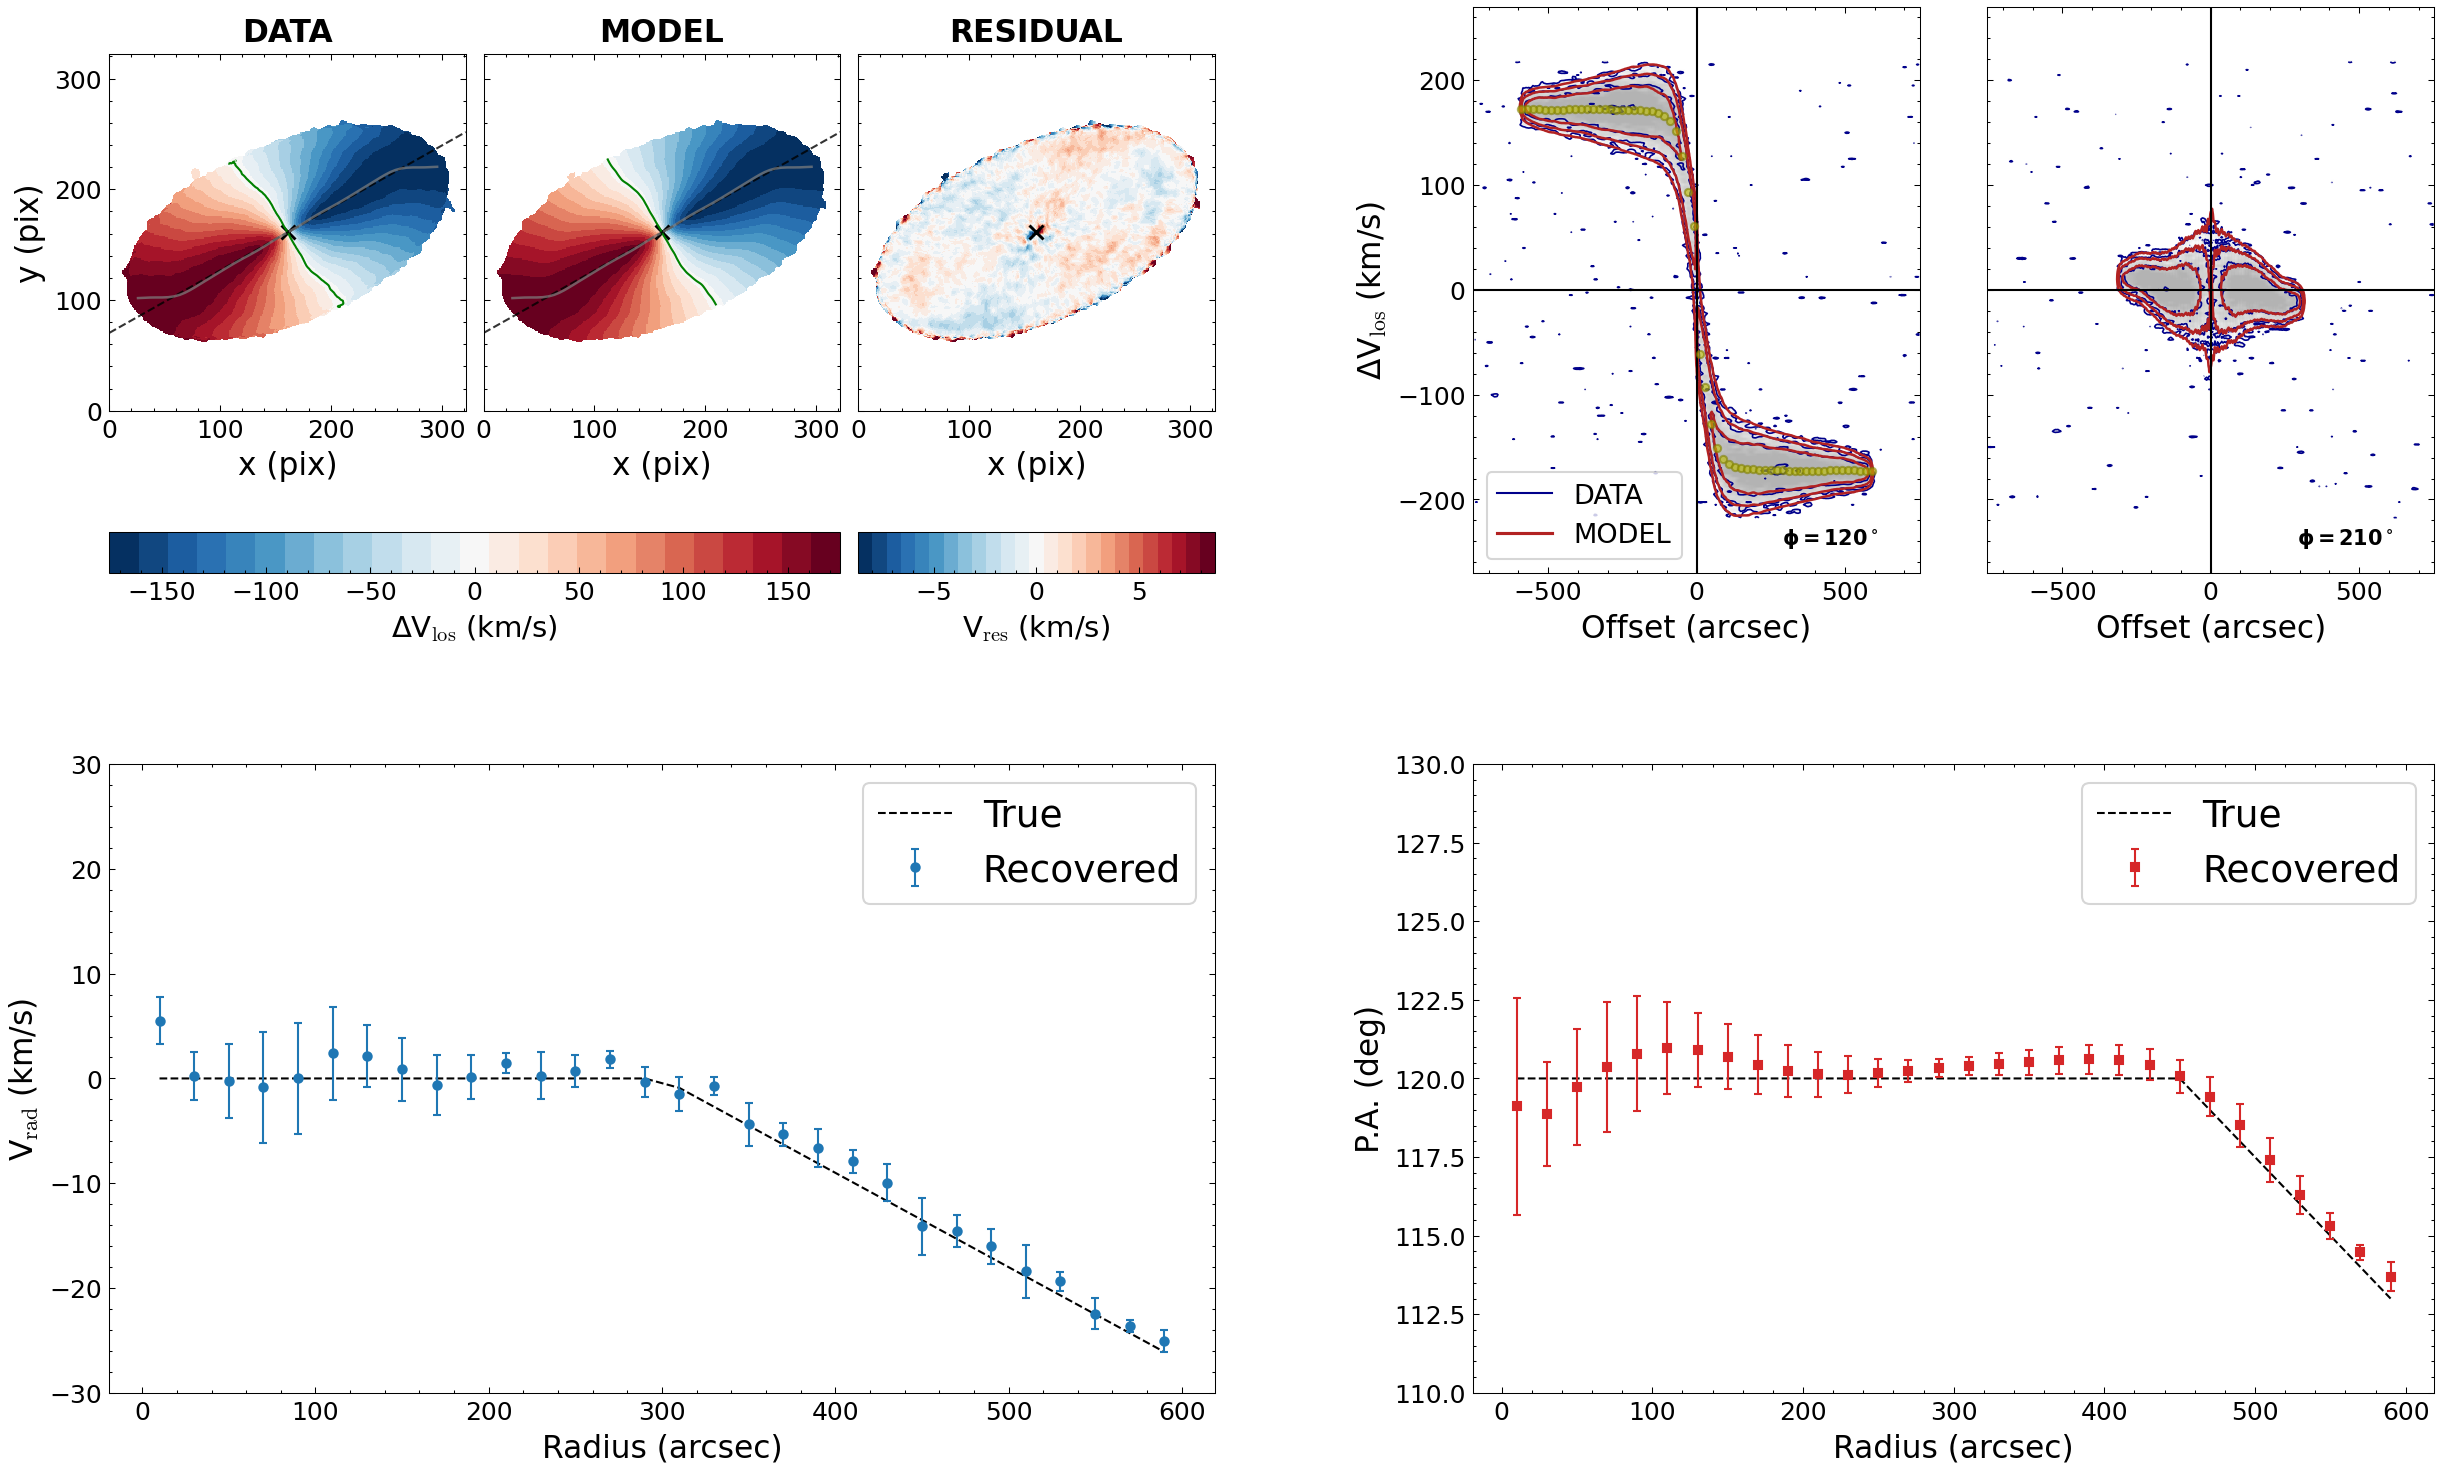

In [12]:
import numpy as np
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

from astropy.io import fits
from astropy.visualization import PercentileInterval, PowerStretch, ImageNormalize
from copy import copy


# ============================================================
# 1. 全局样式
# ============================================================
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")

plt.rcParams["axes.labelsize"] = 15
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
mpl.rcParams["contour.negative_linestyle"] = "solid"
plt.rc("font", family="sans-serif", size=10)

params = {
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "mathtext.default": "regular",
}
plt.rcParams.update(params)


# ============================================================
# 2. 路径与数据
# ============================================================
RING_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/"
RING_MODEL1123 = RING_BASE + "model1123_processed_60/"
INITIAL_1123 = "/net/dataserver3/data/users/linn/para_initial/test_more_model/model1123/"

galaxy = "ring_v200_R50_PAk0.05_TP450_VRk0.09_TP300_INC60"
outfolder = RING_MODEL1123 + galaxy + "/second_step_check_sinw/"
gname = "SNR10Res10mod"

recorver = pd.read_csv(outfolder + "rings_final2.txt", delimiter=r"\s+")
true_ = pd.read_csv(INITIAL_1123 + galaxy + ".txt", delimiter=r"\s+")
error_ = pd.read_csv(RING_MODEL1123 + galaxy + "/bootstrap_error.txt", delimiter=r"\s+")


# ============================================================
# 3. 读取 ring 参数
# ============================================================
rad, inc, pa, xpos, ypos, vsys = np.genfromtxt(
    outfolder + "rings_final2.txt",
    usecols=(1, 4, 5, 9, 10, 11),
    unpack=True,
)

xcen_m, ycen_m, inc_m, pa_m, vsys_m = np.nanmean(
    (xpos, ypos, inc, pa, vsys),
    axis=1,
)

# 和你的 map 脚本保持一致
xmin, xmax = 39, 361
ymin, ymax = 39, 361

xcen = xcen_m - xmin
ycen = ycen_m - ymin

# 你的模型里 1 pix = 4 arcsec
rad_pix = rad / 4.0

try:
    nr = len(rad_pix)
except TypeError:
    nr = 1


# ============================================================
# 4. 读取 moment map
# ============================================================
f1 = fits.open(outfolder + "/maps/" + gname + "_1mom.fits")
mom1 = f1[0].data[ymin:ymax + 1, xmin:xmax + 1]
f1.close()

mod_file_list = sorted([
    f for f in os.listdir(outfolder + "/maps/")
    if "1mom.fits" in f and ("azim" in f or "local" in f)
])

mom1_mod = fits.open(outfolder + "/maps/" + mod_file_list[0])[0].data[
    ymin:ymax + 1, xmin:xmax + 1
]

maskmap = np.copy(mom1)
maskmap[np.isfinite(mom1)] = 1

ext_map = [0, xmax - xmin, 0, ymax - ymin]


# ============================================================
# 5. 开始画图
# ============================================================
fig = plt.figure(figsize=(20, 12), dpi=150)

gs = GridSpec(
    2, 2,
    figure=fig,
    wspace=0.25,
    hspace=0.32,
    height_ratios=[0.9, 1.0],
    width_ratios=[1.15, 1.0],
)


# ============================================================
# 左上：DATA / MODEL / RESIDUAL velocity map
# ============================================================
gs_tl_main = gs[0, 0].subgridspec(
    2, 1,
    height_ratios=[0.88, 0.08],
    hspace=0.3,
)

# 三列：DATA / MODEL / RESIDUAL
gs_tl_maps = gs_tl_main[0, 0].subgridspec(1, 3, wspace=0.05)

# 两个 colorbar：DATA+MODEL 共用一个，RESIDUAL 单独一个
gs_tl_cb = gs_tl_main[1, 0].subgridspec(
    1, 3,
    width_ratios=[1, 1, 1],
    wspace=0.05,
)

cmap_vel = copy(plt.get_cmap("RdBu_r", 25))
cmap_vel.set_bad("w", 1.0)

# DATA 和 MODEL 使用同一个速度色标
data_for_norm = mom1 - vsys_m
interval = PercentileInterval(99.5)
vmin, vmax = interval.get_limits(data_for_norm)
vabs = max(abs(vmin), abs(vmax))
norm_m = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)

# Residual velocity field: DATA - MODEL
# 注意这里不需要再减 vsys，因为系统速度会抵消
res_mom1 = (mom1 - mom1_mod) * maskmap

finite_res = res_mom1[np.isfinite(res_mom1)]
if len(finite_res) > 0:
    vabs_res = np.nanpercentile(np.abs(finite_res), 99.5)
else:
    vabs_res = 1.0

if not np.isfinite(vabs_res) or vabs_res == 0:
    vabs_res = 1.0

norm_res = mpl.colors.Normalize(vmin=-vabs_res, vmax=vabs_res)

map_list = [
    mom1 - vsys_m,
    mom1_mod - vsys_m,
    res_mom1,
]

titles = ["DATA", "MODEL", "RESIDUAL"]
norm_list = [norm_m, norm_m, norm_res]

# global major axis from mean PA
x_major = np.arange(0, xmax - xmin, 0.1)
y_major = np.tan(np.radians(pa_m - 90.0)) * (x_major - xcen) + ycen

for j, d in enumerate(map_list):
    ax = fig.add_subplot(gs_tl_maps[0, j])

    ax.imshow(
        d * maskmap,
        origin="lower",
        cmap=cmap_vel,
        norm=norm_list[j],
        extent=ext_map,
        aspect="equal",
        interpolation="nearest",
    )

    ax.plot(xcen, ycen, "x", color="black", markersize=7, mew=1.4)

    # DATA 和 MODEL：画零速度线、平均主轴和 PA trace
    if j < 2:
        ax.contour(
            d * maskmap,
            levels=[0],
            colors="green",
            origin="lower",
            extent=ext_map,
            linewidths=1.0,
        )

        # mean major axis
        ax.plot(
            x_major,
            y_major,
            "--",
            color="k",
            linewidth=1.0,
            alpha=0.8,
        )

        # warped PA trace
        if nr > 5 and not np.all(np.diff(pa) == 0):
            x_pix = rad_pix * np.cos(np.radians(pa - 90.0))
            y_pix = rad_pix * np.sin(np.radians(pa - 90.0))

            ax.plot(
                xcen - x_pix,
                ycen - y_pix,
                "-",
                color="grey",
                lw=1.2,
                alpha=0.7,
            )
            ax.plot(
                xcen + x_pix,
                ycen + y_pix,
                "-",
                color="grey",
                lw=1.2,
                alpha=0.7,
            )

    # RESIDUAL：可选画零残差线
    # if j == 2:
    #     try:
    #         ax.contour(
    #             res_mom1,
    #             levels=[0],
    #             colors="k",
    #             origin="lower",
    #             extent=ext_map,
    #             linewidths=0.8,
    #             alpha=0.7,
    #         )
    #     except Exception:
    #         pass

    ax.set_xlim(ext_map[0], ext_map[1])
    ax.set_ylim(ext_map[2], ext_map[3])

    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.yaxis.set_major_locator(MultipleLocator(100))

    ax.set_xlabel("x (pix)")
    ax.set_title(titles[j], fontsize=15, fontweight="bold")

    if j == 0:
        ax.set_ylabel("y (pix)")
    else:
        ax.set_yticklabels([])

# DATA + MODEL colorbar
ax_cb_vel = fig.add_subplot(gs_tl_cb[0, 0:2])
cb_vel = ColorbarBase(
    ax_cb_vel,
    orientation="horizontal",
    cmap=cmap_vel,
    norm=norm_m,
)
cb_vel.set_label(r"$\Delta V_{\mathrm{los}}$ (km/s)", fontsize=14)
cb_vel.outline.set_linewidth(0.5)

# RESIDUAL colorbar
ax_cb_res = fig.add_subplot(gs_tl_cb[0, 2])
cb_res = ColorbarBase(
    ax_cb_res,
    orientation="horizontal",
    cmap=cmap_vel,
    norm=norm_res,
)
cb_res.set_label(r"$V_{\mathrm{res}}$ (km/s)", fontsize=14)
cb_res.outline.set_linewidth(0.5)


# ============================================================
# 右上：PV diagrams
# ============================================================
gs_tr = gs[0, 1].subgridspec(1, 2, wspace=0.15)

zmin, zmax = 13, 187

image_maj = fits.open(outfolder + "pvs/" + gname + "_pv_a.fits")
image_min = fits.open(outfolder + "pvs/" + gname + "_pv_b.fits")

mod_pv_a = sorted([
    f for f in os.listdir(outfolder + "pvs/")
    if "pv_a_azim.fits" in f or "pv_a_local.fits" in f
])[0]

mod_pv_b = sorted([
    f for f in os.listdir(outfolder + "pvs/")
    if "pv_b_azim.fits" in f or "pv_b_local.fits" in f
])[0]

im_mod_maj = fits.open(outfolder + "pvs/" + mod_pv_a)
im_mod_min = fits.open(outfolder + "pvs/" + mod_pv_b)

head = image_maj[0].header
crpix = head["CRPIX1"]
cdelt = head["CDELT1"]
crval = head["CRVAL1"]

xminpv = int(crpix - 1 - 162)
xmaxpv = int(crpix - 1 + 162)

xmin_wcs = ((xminpv + 1 - 0.5 - crpix) * cdelt + crval) * 3600
xmax_wcs = ((xmaxpv + 1 + 0.5 - crpix) * cdelt + crval) * 3600

zmin_wcs, zmax_wcs = 255.25, -182.25
ext_pv = [xmin_wcs, xmax_wcs, zmin_wcs - vsys_m, zmax_wcs - vsys_m]

cont = 0.000675824
v_levels = np.array([1, 2, 4, 8, 16, 32, 64]) * cont

norm_pv = ImageNormalize(
    vmin=cont,
    vmax=image_maj[0].data.max() * 0.7,
    stretch=PowerStretch(0.5),
)

pv_datas = [
    image_maj[0].data[zmin:zmax + 1, xminpv:xmaxpv + 1],
    image_min[0].data[zmin:zmax + 1, xminpv:xmaxpv + 1],
]

pv_mods = [
    im_mod_maj[0].data[zmin:zmax + 1, xminpv:xmaxpv + 1],
    im_mod_min[0].data[zmin:zmax + 1, xminpv:xmaxpv + 1],
]

phi_labels = [r"$\phi = 120^\circ$", r"$\phi = 210^\circ$"]

for i in range(2):
    ax = fig.add_subplot(gs_tr[0, i])

    ax.imshow(
        pv_datas[i],
        origin="lower",
        cmap="Greys",
        norm=norm_pv,
        extent=ext_pv,
        aspect="auto",
        alpha=0.3,
    )

    ax.contour(
        pv_datas[i],
        v_levels,
        origin="lower",
        linewidths=0.8,
        colors="#00008B",
        extent=ext_pv,
    )

    ax.contour(
        pv_mods[i],
        v_levels,
        origin="lower",
        linewidths=1.2,
        colors="#B22222",
        extent=ext_pv,
    )

    ax.axhline(y=0, color="black", lw=1)
    ax.axvline(x=0, color="black", lw=1)

    ax.set_ylim(-270, 270)
    ax.set_xlabel("Offset (arcsec)")

    ax.text(
        0.8,
        0.05,
        phi_labels[i],
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        ha="center",
    )

    if i == 0:
        ax.set_ylabel(r"$\Delta V_{\mathrm{los}}$ (km/s)")

        # 如果你前面定义了 radius_pts 和 vlos_pts，就叠加旋转曲线点
        if "radius_pts" in globals() and "vlos_pts" in globals():
            ax.plot(
                radius_pts,
                vlos_pts,
                "y.",
                markersize=7,
                markeredgecolor="olive",
                alpha=0.6,
            )

        legend_elements = [
            Line2D([0], [0], color="#00008B", lw=1, label="DATA"),
            Line2D([0], [0], color="#B22222", lw=1.5, label="MODEL"),
        ]
        ax.legend(
            handles=legend_elements,
            loc="lower left",
            frameon=True,
            fontsize=13,
        )
    else:
        ax.set_yticklabels([])


# ============================================================
# 左下：VRAD
# ============================================================
ax_vrad = fig.add_subplot(gs[1, 0])

ax_vrad.plot(
    true_["RAD(arcs)"],
    true_["VRAD(km/s)"],
    "k--",
    label="True",
)

ax_vrad.errorbar(
    recorver["RAD(arcs)"],
    recorver["VRAD(km/s)"],
    yerr=error_["VRADerror(km/s)"],
    fmt="o",
    color="tab:blue",
    label="Recovered",
    markersize=4,
    capsize=2,
)

ax_vrad.set_xlabel("Radius (arcsec)")
ax_vrad.set_ylabel(r"$V_{\mathrm{rad}}$ (km/s)")
ax_vrad.legend(fontsize=18, frameon=True)
ax_vrad.set_ylim(-30, 30)


# ============================================================
# 右下：PA
# ============================================================
ax_pa = fig.add_subplot(gs[1, 1])

ax_pa.plot(
    true_["RAD(arcs)"],
    true_["P.A.(deg)"],
    "k--",
    label="True",
)

ax_pa.errorbar(
    recorver["RAD(arcs)"],
    recorver["P.A.(deg)"],
    yerr=error_["P.A.error(deg)"],
    fmt="s",
    color="tab:red",
    label="Recovered",
    markersize=4,
    capsize=2,
)

ax_pa.set_xlabel("Radius (arcsec)")
ax_pa.set_ylabel("P.A. (deg)")
ax_pa.legend(fontsize=18, frameon=True)
ax_pa.set_ylim(120 - 10, 120 + 10)


# ============================================================
# 保存
# ============================================================
plt.tight_layout()

plt.savefig(
    "single_galaxy_error_with_maps_pv_2_residual.pdf",
    bbox_inches="tight",
)

plt.show()


# Close FITS files
image_maj.close()
image_min.close()
im_mod_maj.close()
im_mod_min.close()